# Fraud Detection using Unsupervised Learning

## Problem Statement and Approach

---

### Fraud Detection

Credit card fraud costs the global economy billions of dollars annually. Every fraudulent transaction represents a financial loss to banks, merchants and customers. Detecting fraud in real time, before a transaction is processed, is one of the most challenging and important application of machine learning in the finance industry.
However, fraud is rare( *~3-5% of total transactions* ) and ever-evolving. Moreover, fraudulent transaction often look like normal transactions.

---

### Dataset

This project uses the **IEEE-CIS Fraud Detection** dataset from Kaggle, provided by Vesta Corporation. It contains:

- 590,540 transactions
- 394 raw features - transaction details, card information, email domains, device information and 339 anonymized Vesta proprietary features (V-columns)
- 3.5% fraud rate - a heavily imbalanced classification problem
- Two tables: transaction and identity

**Columns**

- TransactionAmt: The monetary value of the transaction in USD
- TransactionDT: Time elapsed in seconds from a reference point
- ProductCD: Product category associated with the transaction
- card1-card6: Card-related features including card type, network, and numerical card attributes
- addr1, addr2: Billing and mailing address zip codes
- dist1: Distance between billing and mailing addresses
- P_emaildomain: Email domain of the purchaser
- R_emaildomain: Email domain of the recipient
- C1-C14: Count features representing how many times a card, address or email has appeared in the dataset
- D1-D15: Timedelta features representing days between the current and previous transactions of various types
- M1-M9: Match features indicating whether card details, addresses or other attributes match on file records
- V1-V339: Anonymized proprietary features engineered by Vesta Corporation
- id_01-id_38: Identity-related features from the identity table including device, browser and network information
- DeviceType: whether the transaction was made from a mobile or desktop device
- DeviceInfo: specific device model or browser engine used for the transaction

---

### Why Unsupervised Learning?

Most fraud detection projects use supervised learning, i.e. train a model on labeled fraud and normal transactions. This works well when labels are abundant and stable. In practice however, two problems arise:

1. Labels are expensive: manually verifying fraud labels requires human investigation. Many transactions can never be conclusively labeled.
2. Fraud patterns evolve: a supervised model trained on last year's fraud patterns may miss entirely new type of attacks.

An unsupervised approach sidesteps both problems. By learning only what normal transactions look like, the model flags anything that deviates significantly, including fraud patterns never seen before.

---

### Approach

This project combines two complementary unsupervised anomaly detection methods:

**Variational Autoencoder (VAE)**: a generative model trained exclusively on normal transactions. The VAE learns to compress and reconstruct normal transaction patterns. Fraudulent transactions, being unlike (more or less) anything in the training data, produce higher reconstruction errors and are flagged as anomalies.

**Isolation Forest**: an ensemble tree method that isolates anomalies by randomly partitioning the feature space. Points that are isolated in fewer partitions are more likely to be anomalies.

>A key finding of this project is that these two models respond differently to the feature set, the VAE performs better without the noisy V-columns while Isolation Forest benefits from them. This complementarity makes their ensemble more powerful than either model individually.

---

### Results Preview

The final ensemble achieves:

AUROC: 0.7269
Average Precision: 0.0904, 166% above the random baseline of 0.035

>Note: Supervised models on this dataset achieve AUROC 0.92+. The gap reflects the fundamental trade-off of unsupervised learning, no label leakage, but a performance ceiling. The goal here is not to match supervised performance but to demonstrate a robust, label-free detection system.

---

## Data Loading

In [2]:
## Importing necessary libraries:
import os

## Data manipulation
import numpy as np
import pandas as pd

## Plotting 
import matplotlib.pyplot as plt
import seaborn as sns

## Setting the plot style
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.size"] = 11

## Machine learning
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
from sklearn.ensemble import IsolationForest

## Deep learning
import torch
from torch.utils.data import Dataset, DataLoader
from torch import from_numpy
from torch import nn

## File saving
import joblib
import json

## Configuration
import warnings
warnings.filterwarnings('ignore')

The transaction dataset is too large to be imported with my RAM configuration hence I first look at random 50,000 rows and try to remove unnecessary columns

In [2]:
total_rows = sum(1 for _ in open("ieee-fraud-detection/train_transaction.csv")) - 1 # -1 for removing the header

no_rows = 50000

np.random.seed(26)
keep_idx = np.random.choice(total_rows, size=no_rows, replace=False)
keep_idx = set(keep_idx)

print(f"Total rows in dataset: {total_rows:,}")
print(f"Sample size: {no_rows:,}")
print(f"Sample fraction: {no_rows/total_rows:.1%}")

sample_df = pd.read_csv("ieee-fraud-detection/train_transaction.csv",skiprows=lambda x: x != 0 and (x-1) not in keep_idx)

Total rows in dataset: 590,540
Sample size: 50,000
Sample fraction: 8.5%


In [3]:
## simple peak at the data.

sample_df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.500,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987036,0,87149,77.000,W,4806,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987066,0,87660,300.000,H,15333,562.0,150.0,visa,226.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2987068,0,87667,3.081,C,14076,545.0,185.0,visa,147.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987078,0,87825,300.000,W,14858,558.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
## Looking at missing rate amoung different columns

missing_rates = sample_df.isna().mean().sort_values(ascending=False)
print(missing_rates.head(170))

dist2    0.93672
D7       0.93336
D13      0.89526
D14      0.89512
D12      0.89008
          ...   
V259     0.75996
V239     0.75996
V251     0.75996
dist1    0.59676
M5       0.59206
Length: 170, dtype: float64


In [3]:
## Keep columns with less than 70% missing values

cols_to_keep = [c for c in sample_df.columns if sample_df[c].isna().mean() < 0.7]
print(f"Number of columns remaining: {len(cols_to_keep)}")

Number of columns remaining: 226


The threshold is set to 70% to agressively drop columns that would essentially act as noise and hinder the unsupervised learning models. Rest of the colums will be further scrutinized after importing the full dataset.

In [4]:
## Load full dataset with only the pre-selected columns to avoid memory issues

df_transaction = pd.read_csv("ieee-fraud-detection/train_transaction.csv",usecols=cols_to_keep)

In [7]:
## peaking at the dataset

df_transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 226 entries, TransactionID to V321
dtypes: float64(209), int64(4), object(13)
memory usage: 1018.2+ MB


In [8]:
## Verifying the sample was indeed indicative of the entire dataset

df_transaction.isna().mean().sort_values(ascending = False).head(10)

dist1    0.596524
M5       0.593494
M7       0.586353
M8       0.586331
M9       0.586331
D5       0.524674
M4       0.476588
D2       0.475492
V7       0.472935
V6       0.472935
dtype: float64

In [10]:
## Reading the identity dataset

df_identity = pd.read_csv("ieee-fraud-detection/train_identity.csv")

In [10]:
## size of both dataset

print(f"Transaction dataset shape: {df_transaction.shape}")
print(f"Identity dataset shape: {df_identity.shape}")

Transaction dataset shape: (590540, 226)
Identity dataset shape: (144233, 41)


I clean each table independently to keep the feature selection reasoning clear and manageable within memory constraints. After cleaning, I merge on TransactionID using a left join, preserving all transactions regardless of whether identity records exist.

## Cleaning and Feature Engineering

---

### V-columns

I first start by cleaning or dropping the V-columns in the transaction table. 

>Note: The V-columns are known to have very high correlations and can be very sparse coulmns. 

In [11]:
## Seperating out the V-columns

v_cols = [c for c in df_transaction.columns if c.startswith('V')]
v_cols_sorted = df_transaction[v_cols].isna().mean().sort_values(ascending= True).index.tolist()
print(f"Number of V-cols: {len(v_cols_sorted)}")

Number of V-cols: 180


The V-columns are sorted according to missing value to ensure columns with more data is kept in the correlation matrix.
I used correlation matrix to drop columns which have very high correlations. A correlation threshold of 0.75 was chosen to aggressively remove redundant V-columns while retaining genuinely distinct features.

In [12]:
## Dropping highly correlated columns

corr_matrix = df_transaction[v_cols_sorted].corr().abs() 
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.75)]
df_transaction = df_transaction.drop(columns=to_drop)

In [13]:
## Checking how many V-columns are left

v_cols = [c for c in df_transaction.columns if c.startswith('V')]
print(f"Number of V-columns left: {len(v_cols)}")

Number of V-columns left: 54


Next, Columns which are essentially sparse are seperated out and dropped. The threshold is set to 0.9 to ensure no data is lost while still removing unnecessary noise. 

In [14]:
## Checking for sparse columns and removing them

dominant_proportion = df_transaction[v_cols].apply(lambda x: x.value_counts(normalize=True).iloc[0])
sparse_v_cols = dominant_proportion[dominant_proportion > 0.90].index.tolist()
df_transaction = df_transaction.drop(columns=sparse_v_cols)

print(f"Number of V-columns left: {len([c for c in df_transaction.columns if c.startswith('V')])}")

Number of V-columns left: 19


---

### C-columns

Next I move onto the C-columns in the transaction table. 
 

In [45]:
## Checking the C-cols for missing value.

C_cols = [c for c in df_transaction.columns if c.startswith('C')]

df_transaction[C_cols].isnull().mean().sort_values(ascending = False)

C1     0.0
C2     0.0
C3     0.0
C4     0.0
C5     0.0
C6     0.0
C7     0.0
C8     0.0
C9     0.0
C10    0.0
C11    0.0
C12    0.0
C13    0.0
C14    0.0
dtype: float64

The C-columns have no missing value which is good but lets look at the distribution and correlation matrix.

In [16]:
## looking at the distributions

df_transaction[C_cols].describe()

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14
count,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000
mean,14.092458,15.269734,0.005644,4.092185,5.571526,9.071082,2.848478,5.144574,4.480240,5.240343,10.241521,4.076227,32.539918,8.295215
std,133.569018,154.668899,0.150536,68.848459,25.786976,71.508467,61.727304,95.378574,16.674897,95.581443,94.336292,86.666218,129.364844,49.544262
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
50%,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,1.000000
75%,3.000000,3.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,2.000000,0.000000,2.000000,0.000000,12.000000,2.000000
max,4685.000000,5691.000000,26.000000,2253.000000,349.000000,2253.000000,2255.000000,3331.000000,210.000000,3257.000000,3188.000000,3188.000000,2918.000000,1429.000000


This clearly shows that all the columns have highly skewed distributions

In [63]:
## Correlation matrix

corr_matrix = df_transaction[dominant_proportion.sort_values(ascending=True).index.tolist()].corr().abs()
corr_matrix

,C13,C9,C2,C1,C14,C6,C5,C11,C8,C4,C10,C12,C7,C3
C13,1.000000,0.704056,0.751221,0.774603,0.880722,0.808531,0.717509,0.779286,0.653245,0.644549,0.653941,0.631704,0.632394,0.007747
C9,0.704056,1.000000,0.133566,0.175999,0.397396,0.250695,0.925786,0.182446,0.014492,0.015970,0.014731,0.012212,0.012399,0.010074
C2,0.751221,0.133566,1.000000,0.995089,0.936148,0.974845,0.126540,0.993898,0.975863,0.972134,0.970624,0.940258,0.938867,0.003339
C1,0.774603,0.175999,0.995089,1.000000,0.951761,0.982238,0.165862,0.996515,0.967746,0.967800,0.958202,0.927939,0.926258,0.003467
C14,0.880722,0.397396,0.936148,0.951761,1.000000,0.984201,0.378950,0.962465,0.860246,0.907676,0.853009,0.793936,0.794701,0.005091
C6,0.808531,0.250695,0.974845,0.982238,0.984201,1.000000,0.232409,0.991105,0.921972,0.962319,0.914440,0.858182,0.858583,0.004711
C5,0.717509,0.925786,0.126540,0.165862,0.378950,0.232409,1.000000,0.168862,0.011654,0.012842,0.011846,0.009875,0.009970,0.008101
C11,0.779286,0.182446,0.993898,0.996515,0.962465,0.991105,0.168862,1.000000,0.962722,0.974547,0.956056,0.915693,0.915209,0.003583
C8,0.653245,0.014492,0.975863,0.967746,0.860246,0.921972,0.011654,0.962722,1.000000,0.959995,0.996970,0.983027,0.982983,0.001203
C4,0.644549,0.015970,0.972134,0.967800,0.907676,0.962319,0.012842,0.974547,0.959995,1.000000,0.952466,0.894619,0.895092,0.001720


The correlation matrix shows that the columns are heavily correlated and need to be dropped

In [64]:
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
print(f"Columns to be dropped: {to_drop}")

Columns to be dropped: ['C1', 'C14', 'C6', 'C5', 'C11', 'C8', 'C4', 'C10', 'C12', 'C7']


Here there is a problem, C3 is essentially a sparse column and useless here, C5 and C9 are highly correlated columns, however C9 is a better rep for the two column so in the end selecting C1 and C9 makes more sense.

In [66]:
to_drop = ['C2', 'C4', 'C6', 'C7', 'C8', 'C5', 'C10', 'C11', 'C12', 'C14', 'C3']
df_transaction = df_transaction.drop(columns=to_drop)

In [67]:
C_cols = [c for c in df_transaction.columns if c.startswith('C')]
df_transaction[C_cols].describe()

,C2,C3,C9,C13
count,590540.000000,590540.000000,590540.000000,590540.000000
mean,15.269734,0.005644,4.480240,32.539918
std,154.668899,0.150536,16.674897,129.364844
min,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,1.000000
50%,1.000000,0.000000,1.000000,3.000000
75%,3.000000,0.000000,2.000000,12.000000
max,5691.000000,26.000000,210.000000,2918.000000


This looks much better for now. Maybe the columns can be log tansformed after checking for skewness.

---

### D-columns

Next I move onto the D-columns in the transaction table. 
 

In [21]:
## checking the D-columns for msising values

D_cols = [c for c in df_transaction.columns if c.startswith('D')] 
df_transaction[D_cols].isnull().mean().sort_values(ascending = False)

D5     0.524674
D2     0.475492
D11    0.472935
D3     0.445149
D4     0.286047
D15    0.150901
D10    0.128733
D1     0.002149
dtype: float64

The D-columns have some missing value but nothing that would require direct dropping of columns. I take a closer look at the distribution and correlation matrix next.

In [22]:
## looking at the distributions

df_transaction[D_cols].describe()

,D1,D2,D3,D4,D5,D10,D11,D15
count,589271.000000,309743.000000,327662.000000,421618.000000,280699.000000,514518.000000,311253.000000,501427.000000
mean,94.347568,169.563231,28.343348,140.002441,42.335965,123.982137,146.621465,163.744579
std,157.660387,177.315865,62.384721,191.096774,89.000144,182.615225,186.042622,202.726660
min,0.000000,0.000000,0.000000,-122.000000,0.000000,0.000000,-53.000000,-83.000000
25%,0.000000,26.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,3.000000,97.000000,8.000000,26.000000,10.000000,15.000000,43.000000,52.000000
75%,122.000000,276.000000,27.000000,253.000000,32.000000,197.000000,274.000000,314.000000
max,640.000000,640.000000,819.000000,869.000000,819.000000,876.000000,670.000000,879.000000


These columns might be skewed or contain outliers 

In [23]:
## Correlation matrix

df_transaction[D_cols].corr().abs()

,D1,D2,D3,D4,D5,D10,D11,D15
D1,1.000000,0.981311,0.280423,0.585714,0.055236,0.562145,0.592629,0.638957
D2,0.981311,1.000000,0.266112,0.570017,0.238365,0.525967,0.563220,0.618243
D3,0.280423,0.266112,1.000000,0.149038,0.707425,0.092362,0.055433,0.141511
D4,0.585714,0.570017,0.149038,1.000000,0.313650,0.636928,0.657797,0.751546
D5,0.055236,0.238365,0.707425,0.313650,1.000000,0.116784,0.058496,0.188533
D10,0.562145,0.525967,0.092362,0.636928,0.116784,1.000000,0.609652,0.712252
D11,0.592629,0.563220,0.055433,0.657797,0.058496,0.609652,1.000000,0.765000
D15,0.638957,0.618243,0.141511,0.751546,0.188533,0.712252,0.765000,1.000000


D1 and D2 are highly correlated, looking at the missing value, it is better to drop D2

In [24]:
df_transaction = df_transaction.drop(columns = ["D2"])

---

### M-columns

Next I move onto the M-columns in the transaction table. 
 

In [25]:
## Checking the M-columns for missing value

M_cols = [c for c in df_transaction.columns if c.startswith('M')]
df_transaction[M_cols].isnull().mean().sort_values(ascending = False)

M5    0.593494
M7    0.586353
M8    0.586331
M9    0.586331
M4    0.476588
M1    0.459071
M3    0.459071
M2    0.459071
M6    0.286788
dtype: float64

The M-columns have some missing value but nothing that would require direct dropping of columns. I take a closer look at the distribution and correlation matrix next.

In [26]:
## Looking at the distribution

df_transaction[M_cols].describe()

,M1,M2,M3,M4,M5,M6,M7,M8,M9
count,319440,319440,319440,309096,240058,421180,244275,244288,244288
unique,2,2,2,3,2,2,2,2,2
top,T,T,T,M0,F,F,F,F,T
freq,319415,285468,251731,196405,132491,227856,211374,155251,205656


In [27]:
## Converting to numbers to check the correlation matrix

M_cols_binary = [c for c in df_transaction.columns if c.startswith('M') and c != 'M4']
M_encoded = df_transaction[M_cols_binary].apply(lambda x: x.map({'T': 1, 'F': 0}))
M_encoded['M4'] = df_transaction['M4'].map({'M0': 0, 'M1': 1, 'M2': 2})

corr_matrix = M_encoded.corr().abs()
corr_matrix

,M1,M2,M3,M5,M6,M7,M8,M9,M4
M1,1.000000,0.022202,0.017058,0.000482,0.002873,0.001790,0.003438,0.008035,0.002807
M2,0.022202,1.000000,0.665161,0.017961,0.037023,0.098407,0.177217,0.408110,0.008642
M3,0.017058,0.665161,1.000000,0.011867,0.021657,0.060444,0.098663,0.232560,0.014191
M5,0.000482,0.017961,0.011867,1.000000,0.035068,0.007124,0.015034,0.171504,0.010015
M6,0.002873,0.037023,0.021657,0.035068,1.000000,0.082266,0.084646,0.090393,0.011648
M7,0.001790,0.098407,0.060444,0.007124,0.082266,1.000000,0.493290,0.169445,0.004961
M8,0.003438,0.177217,0.098663,0.015034,0.084646,0.493290,1.000000,0.323376,0.002009
M9,0.008035,0.408110,0.232560,0.171504,0.090393,0.169445,0.323376,1.000000,0.010852
M4,0.002807,0.008642,0.014191,0.010015,0.011648,0.004961,0.002009,0.010852,1.000000


These do not seem to be highly correlated. Hence we do not drop any columns.

---

### card-columns

Next I move onto the card-columns in the transaction table. 


In [28]:
## Checking the car-columns for missing value

card_cols = [c for c in df_transaction.columns if c.startswith('card')]
df_transaction[card_cols].isna().mean().sort_values(ascending=False)

card2    0.015127
card5    0.007212
card4    0.002670
card6    0.002660
card3    0.002650
card1    0.000000
dtype: float64

Number of missing values do not seem to be very large.

In [29]:
df_transaction[card_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   card1   590540 non-null  int64  
 1   card2   581607 non-null  float64
 2   card3   588975 non-null  float64
 3   card4   588963 non-null  object 
 4   card5   586281 non-null  float64
 5   card6   588969 non-null  object 
dtypes: float64(3), int64(1), object(2)
memory usage: 27.0+ MB


card1,2,3,5 are numerical and card4,6 are categorical. I look at each group seperately.

In [30]:
card_num = ["card1","card2","card3","card5"]
card_cat = ["card4","card6"]

In [31]:
## Numerical columns distribution

df_transaction[card_num].describe()

,card1,card2,card3,card5
count,590540.000000,581607.000000,588975.000000,586281.000000
mean,9898.734658,362.555488,153.194925,199.278897
std,4901.170153,157.793246,11.336444,41.244453
min,1000.000000,100.000000,100.000000,100.000000
25%,6019.000000,214.000000,150.000000,166.000000
50%,9678.000000,361.000000,150.000000,226.000000
75%,14184.000000,512.000000,150.000000,226.000000
max,18396.000000,600.000000,231.000000,237.000000


In [32]:
## Correlation matrix

df_transaction[card_num].corr().abs()

,card1,card2,card3,card5
card1,1.000000,0.004960,0.002965,0.093633
card2,0.004960,1.000000,0.023816,0.030486
card3,0.002965,0.023816,1.000000,0.158383
card5,0.093633,0.030486,0.158383,1.000000


The columns do not have high correlations, however card3 and card5 seem to be sparse columns, I check whether the columns are filled with one or two values only next.

In [33]:
for col in ["card3","card5"]:
    non_null = df_transaction[col].dropna()
    dominant = non_null.value_counts(normalize=True).iloc[0]
    print(f"\n{col} — {len(non_null)} non-null rows, dominant value: {dominant:.2%}")
    print(non_null.value_counts(normalize=True).head(5))


card3 — 588975 non-null rows, dominant value: 88.51%
card3
150.0    0.885075
185.0    0.095668
106.0    0.002667
146.0    0.002126
144.0    0.002126
Name: proportion, dtype: float64

card5 — 586281 non-null rows, dominant value: 50.58%
card5
226.0    0.505809
224.0    0.139034
166.0    0.097462
102.0    0.049643
117.0    0.044247
Name: proportion, dtype: float64


Since card3 is composed of essentially a single value (~89% is 150), this will essentially be noise for the VAE, we drop it.

In [34]:
df_transaction = df_transaction.drop(columns=["card3"])

In [35]:
## Categorical columns distribution

df_transaction[card_cat].describe()

,card4,card6
count,588963,588969
unique,4,4
top,visa,debit
freq,384767,439938


In [36]:
## Looking at crosstable

pd.crosstab(df_transaction['card4'], df_transaction['card6'])

card6,charge card,credit,debit,debit or credit
card4,,,,
american express,3,8175,144,0
discover,0,6304,347,0
mastercard,0,50772,138415,30
visa,12,83732,301023,0


---

### addr1, addr2, dist1 columns

Next I move onto the addr1, addr2 columns in the transaction table. 


In [37]:
## Looking for missing values

df_transaction[["addr1","addr2","dist1"]].isnull().mean()

addr1    0.111264
addr2    0.111264
dist1    0.596524
dtype: float64

Not a lot of missing values, but identical number of missing values can be a sign of high correlation

In [38]:
## Looking at the distribution

df_transaction[["addr1","addr2","dist1"]].describe()

,addr1,addr2,dist1
count,524834.000000,524834.000000,238269.000000
mean,290.733794,86.800630,118.502180
std,101.741072,2.690623,371.872026
min,100.000000,10.000000,0.000000
25%,204.000000,87.000000,3.000000
50%,299.000000,87.000000,8.000000
75%,330.000000,87.000000,24.000000
max,540.000000,102.000000,10286.000000


In [39]:
## Correlation matrix

df_transaction[["addr1","addr2","dist1"]].corr().abs()

,addr1,addr2,dist1
addr1,1.000000,0.002765,0.001212
addr2,0.002765,1.000000,0.038691
dist1,0.001212,0.038691,1.000000


addr2 to might be a sparse column, so I check for this

In [40]:
non_null = df_transaction["addr2"].dropna()
dominant = non_null.value_counts(normalize=True).iloc[0]
print(f"\n{"addr2"} — {len(non_null)} non-null rows, dominant value: {dominant:.2%}")
print(non_null.value_counts(normalize=True).head(5))


addr2 — 524834 non-null rows, dominant value: 99.17%
addr2
87.0    0.991706
60.0    0.005876
96.0    0.001216
32.0    0.000173
65.0    0.000156
Name: proportion, dtype: float64


This is essentially a sparse column and we can drop it

In [41]:
df_transaction = df_transaction.drop(columns=["addr2"])

---

### P_emaildomain column

Next I move onto the P_emaildomain column in the transaction table. 


In [42]:
## Looking for unique values

print(df_transaction["P_emaildomain"].value_counts())
print(f"Proportion of missing values: {df_transaction["P_emaildomain"].isna().mean()}")

P_emaildomain
gmail.com           228355
yahoo.com           100934
hotmail.com          45250
anonymous.com        36998
aol.com              28289
comcast.net           7888
icloud.com            6267
outlook.com           5096
msn.com               4092
att.net               4033
live.com              3041
sbcglobal.net         2970
verizon.net           2705
ymail.com             2396
bellsouth.net         1909
yahoo.com.mx          1543
me.com                1522
cox.net               1393
optonline.net         1011
charter.net            816
live.com.mx            749
rocketmail.com         664
mail.com               559
earthlink.net          514
gmail                  496
outlook.es             438
mac.com                436
juno.com               322
aim.com                315
hotmail.es             305
roadrunner.com         305
windstream.net         305
hotmail.fr             295
frontier.com           280
embarqmail.com         260
web.de                 240
netzero.com   

These are too many categories, we bin the categories together to reduce the number of categories to 6-8. This help during Labelencoding/Onehotencoding. 
>Note: it is important to not look at labels while binning to prevent label/data leaks. 

In [43]:
## Bining

def clean_email(x):
    x = str(x).lower()
    if 'gmail' in x: return 'gmail'
    if 'yahoo' in x or "ymail" in x: return 'yahoo'
    if 'hotmail' in x: return 'hotmail'
    if 'icloud' in x or "mac" in x: return 'icloud'
    if 'anonymous' in x: return 'anonymous'
    if 'outlook' in x or 'live' in x or 'msn' in x: return 'microsoft'
    if 'missing' in x: return 'missing'
    if 'nan' in x: return np.nan
    return 'other'

df_transaction["P_emaildomain"] = df_transaction["P_emaildomain"].apply(clean_email)

In [44]:
df_transaction["P_emaildomain"].value_counts()

P_emaildomain
gmail        228851
yahoo        105305
other         58750
hotmail       46005
anonymous     36998
microsoft     13472
icloud         6703
Name: count, dtype: int64

This looks way better.

---

### ProductCD column

Next I move onto the ProductCD column in the transaction table. 


In [45]:
## Checking ProductCD column

print(df_transaction["ProductCD"].value_counts())
print(f"Proportion of missing data: {df_transaction["ProductCD"].isna().mean()}")

ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64
Proportion of missing data: 0.0


This column does not require any cleaning

---

### TransactionAmt column

Next I move onto the TransactionAmt column in the transaction table. 


In [46]:
## Looking for missing values

print(f"Proportion of missing value: {df_transaction["TransactionAmt"].isna().mean()}")

Proportion of missing value: 0.0


No missing value is great news, lets look at the distribution.

In [47]:
## Distribution

df_transaction["TransactionAmt"].describe()

count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

The distribution looks skewed and has an extreme outlier (two overlapping values) (revelaed during EDA). This outlier is removed already for the sake of uniformity

In [49]:
idmax = df_transaction[df_transaction['TransactionAmt'] == max(df_transaction["TransactionAmt"])].index
print(f"max Transaction Amt: {max(df_transaction["TransactionAmt"])}")
df_transaction = df_transaction.drop(index=idmax[0])
idmax = df_transaction[df_transaction['TransactionAmt'] == max(df_transaction["TransactionAmt"])].index
print(f"max Transaction Amt: {max(df_transaction["TransactionAmt"])}")
df_transaction = df_transaction.drop(index=idmax[0])
print(f"max Transaction Amt: {max(df_transaction["TransactionAmt"])}")

max Transaction Amt: 31937.391
max Transaction Amt: 31937.391
max Transaction Amt: 6450.97


---

### TransactionDT column

Next I move onto the TransactionDT column in the transaction table. 


In [50]:
## Looking for missing values

print(f"Proportion of missing value: {df_transaction["TransactionDT"].isna().mean()}")

Proportion of missing value: 0.0


No missing value is great news, lets look at the distribution.

In [51]:
## Distribution

df_transaction["TransactionDT"].describe()

count    5.905380e+05
mean     7.372314e+06
std      4.617231e+06
min      8.640000e+04
25%      3.027043e+06
50%      7.306548e+06
75%      1.124665e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64

In [52]:
## Get hours and days of the week from Transaction DT

df_transaction['hour'] = (df_transaction['TransactionDT'] // 3600) % 24
df_transaction['day_of_week'] = (df_transaction['TransactionDT'] // (3600 * 24)) % 7

Hours and days of week helps us see if fraudulant transactions follow some kind of time cycle.

---

### id-columns

Next I move onto the id-columns in the identity table. 


In [53]:
id_col = [c for c in df_identity.columns if c.startswith("id")]

In [54]:
## Checking for missing values

df_identity[id_col].isna().mean().sort_values(ascending=False).index.tolist()
to_drop = [c for c in id_col if df_identity[c].isna().mean() > 0.9]
df_identity = df_identity.drop(columns=to_drop)

The columns with more than 90% missing values are dropped as these would essentially act as noise.

In [55]:
id_col = [c for c in df_identity.columns if c.startswith("id")]
id_num_col = df_identity[id_col].select_dtypes(include = "number").columns.tolist()
id_cat_col = df_identity[id_col].select_dtypes(include = "object").columns.tolist()
print(f"Number of numerical columns: {len(id_num_col)}")
print(f"Number of categorical columns: {len(id_cat_col)}")

Number of numerical columns: 16
Number of categorical columns: 13


Since columns amoung these could be sparse, I drop these before so as to see the distribution clearly.

In [56]:
## Looking at numerical id columns

dominant_proportion = df_identity[id_num_col].apply(lambda x: x.value_counts(normalize=True).iloc[0])
sparse_id_cols = dominant_proportion[dominant_proportion > 0.90].index.tolist()
df_identity = df_identity.drop(columns=sparse_id_cols)

id_col = [c for c in df_identity.columns if c.startswith("id")]
id_num_col = df_identity[id_col].select_dtypes(include = "number").columns.tolist()
print(f"Number of numerical id-columns left: {len(id_num_col)}")

Number of numerical id-columns left: 11


In [57]:
## Distribution

df_identity[id_num_col].describe()

,id_01,id_02,id_05,id_06,id_13,id_14,id_17,id_18,id_19,id_20,id_32
count,144233.000000,140872.000000,136865.000000,136865.000000,127320.000000,80044.000000,139369.000000,45113.000000,139318.000000,139261.000000,77586.000000
mean,-10.170502,174716.584708,1.615585,-6.698710,48.053071,-344.507146,189.451377,14.237337,353.128174,403.882666,26.508597
std,14.347949,159651.816856,5.249856,16.491104,11.774858,93.695502,30.375360,1.561302,141.095343,152.160327,3.737502
min,-100.000000,1.000000,-72.000000,-100.000000,10.000000,-660.000000,100.000000,10.000000,100.000000,100.000000,0.000000
25%,-10.000000,67992.000000,0.000000,-6.000000,49.000000,-360.000000,166.000000,13.000000,266.000000,256.000000,24.000000
50%,-5.000000,125800.500000,0.000000,0.000000,52.000000,-300.000000,166.000000,15.000000,341.000000,472.000000,24.000000
75%,-5.000000,228749.000000,1.000000,0.000000,52.000000,-300.000000,225.000000,15.000000,427.000000,533.000000,32.000000
max,0.000000,999595.000000,52.000000,0.000000,64.000000,720.000000,229.000000,29.000000,671.000000,661.000000,32.000000


In [58]:
## Correlation matrix

df_identity[id_num_col].corr().abs()

,id_01,id_02,id_05,id_06,id_13,id_14,id_17,id_18,id_19,id_20,id_32
id_01,1.000000,0.142064,0.009666,0.201637,0.088596,0.085331,0.180504,0.016626,0.000519,0.071238,0.004386
id_02,0.142064,1.000000,0.101547,0.047041,0.035814,0.037694,0.412987,0.142657,0.093068,0.108523,0.130711
id_05,0.009666,0.101547,1.000000,0.291584,0.036637,0.001985,0.203021,0.137848,0.023800,0.058070,0.099603
id_06,0.201637,0.047041,0.291584,1.000000,0.074835,0.029647,0.028708,0.048905,0.029647,0.071015,0.086302
id_13,0.088596,0.035814,0.036637,0.074835,1.000000,0.031033,0.075997,0.026072,0.017657,0.029427,0.208539
id_14,0.085331,0.037694,0.001985,0.029647,0.031033,1.000000,0.086848,0.126425,0.074575,0.358147,0.015527
id_17,0.180504,0.412987,0.203021,0.028708,0.075997,0.086848,1.000000,0.231251,0.214211,0.278472,0.017577
id_18,0.016626,0.142657,0.137848,0.048905,0.026072,0.126425,0.231251,1.000000,0.019727,0.164160,0.069000
id_19,0.000519,0.093068,0.023800,0.029647,0.017657,0.074575,0.214211,0.019727,1.000000,0.088309,0.084210
id_20,0.071238,0.108523,0.058070,0.071015,0.029427,0.358147,0.278472,0.164160,0.088309,1.000000,0.003568


The id-columns do not seem to have high correlations, just to dive a bit more deep I check if most of the columns are dominated by a single value.

In [59]:
for col in id_num_col:
    non_null = df_identity[col].dropna()
    dominant = non_null.value_counts(normalize=True).iloc[0]
    print(f"\n{col} — {len(non_null)} non-null rows, dominant value: {dominant:.2%}")
    print(non_null.value_counts(normalize=True).head(5))


id_01 — 144233 non-null rows, dominant value: 56.97%
id_01
-5.0     0.569703
 0.0     0.135579
-10.0    0.078047
-20.0    0.077728
-15.0    0.039339
Name: proportion, dtype: float64

id_02 — 140872 non-null rows, dominant value: 0.01%
id_02
1102.0    0.000078
696.0     0.000071
1120.0    0.000064
1083.0    0.000064
1141.0    0.000064
Name: proportion, dtype: float64

id_05 — 136865 non-null rows, dominant value: 67.76%
id_05
0.0    0.677624
1.0    0.060593
2.0    0.036072
3.0    0.028159
4.0    0.021488
Name: proportion, dtype: float64

id_06 — 136865 non-null rows, dominant value: 66.73%
id_06
 0.0    0.667263
-1.0    0.034245
-5.0    0.028123
-6.0    0.023797
-9.0    0.019245
Name: proportion, dtype: float64

id_13 — 127320 non-null rows, dominant value: 45.63%
id_13
52.0    0.456323
49.0    0.207077
64.0    0.113329
33.0    0.078919
27.0    0.028794
Name: proportion, dtype: float64

id_14 — 80044 non-null rows, dominant value: 55.12%
id_14
-300.0    0.551209
-360.0    0.208148
-480

The columns with more than a 50% as a single value, needs to be investigated further as later i will carry out imputation with median and if lot of missing values are present, these columns will become sparse.

In [60]:
id_list = ["id_01","id_05","id_06","id_13","id_14","id_17","id_18","id_32"]
check_df = df_identity[id_list].fillna(df_identity[id_list].median()) # this is temporary filling to check the sparsness.

In [61]:
for col in id_list:
    non_null = check_df[col].dropna()
    dominant = non_null.value_counts(normalize=True).iloc[0]
    print(f"\n{col} — {len(non_null)} non-null rows, dominant value: {dominant:.2%}")
    print(non_null.value_counts(normalize=True).head(5))


id_01 — 144233 non-null rows, dominant value: 56.97%
id_01
-5.0     0.569703
 0.0     0.135579
-10.0    0.078047
-20.0    0.077728
-15.0    0.039339
Name: proportion, dtype: float64

id_05 — 144233 non-null rows, dominant value: 69.41%
id_05
0.0    0.694092
1.0    0.057497
2.0    0.034229
3.0    0.026721
4.0    0.020391
Name: proportion, dtype: float64

id_06 — 144233 non-null rows, dominant value: 68.43%
id_06
 0.0    0.684261
-1.0    0.032496
-5.0    0.026686
-6.0    0.022582
-9.0    0.018262
Name: proportion, dtype: float64

id_13 — 144233 non-null rows, dominant value: 52.01%
id_13
52.0    0.520075
49.0    0.182795
64.0    0.100040
33.0    0.069665
27.0    0.025417
Name: proportion, dtype: float64

id_14 — 144233 non-null rows, dominant value: 75.09%
id_14
-300.0    0.750938
-360.0    0.115514
-480.0    0.089376
-420.0    0.031491
-600.0    0.003453
Name: proportion, dtype: float64

id_17 — 144233 non-null rows, dominant value: 57.89%
id_17
166.0    0.578890
225.0    0.394972
102.

I drop the columns that are very heavily dominated by one or two values.

In [62]:
to_drop = ["id_14","id_17","id_18","id_32"]
df_identity = df_identity.drop(columns=to_drop)

In [63]:
id_col = [c for c in df_identity.columns if c.startswith("id")]
id_num_col = df_identity[id_col].select_dtypes(include = "number").columns.tolist()
print(f"Number of numerical id-columns left: {len(id_num_col)}")

Number of numerical id-columns left: 7


Next lets look at the categorical columns

In [64]:
df_identity[id_cat_col].nunique()

id_12      2
id_15      3
id_16      2
id_28      2
id_29      2
id_30     75
id_31    130
id_33    260
id_34      4
id_35      2
id_36      2
id_37      2
id_38      2
dtype: int64

Two-four categories is acceptable, however id_30,id_31 and id_33 needs to be binned as they have too many categories.

In [65]:
## id_30

df_identity["id_30"].value_counts().head(30)

id_30
Windows 10          21155
Windows 7           13110
iOS 11.2.1           3722
iOS 11.1.2           3699
Android 7.0          2871
Mac OS X 10_12_6     2559
Mac OS X 10_11_6     2348
iOS 11.3.0           2016
Windows 8.1          1914
Mac OS X 10_10_5     1651
iOS 11.2.6           1647
iOS 10.3.3           1558
Mac OS X 10_13_2     1421
Mac OS X 10_13_1     1211
iOS 11.2.5           1200
Linux                1136
Android              1079
iOS 11.2.2            902
Mac OS X 10_13_3      860
iOS 11.2.0            852
Mac OS X 10_13_4      759
iOS 11.1.1            700
iOS 11.0.3            659
Android 7.1.1         630
Mac OS X 10_9_5       570
Android 6.0.1         566
iOS 10.3.2            428
iOS 9.3.5             414
Android 5.1.1         350
Android 8.0.0         343
Name: count, dtype: int64

In [66]:
## Bining id_30

def clean_id30(x):
    x = str(x).lower()
    if 'missing' in x: return 'missing'
    if 'windows' in x: return 'windows'
    if 'ios' in x or 'iphone' in x: return 'ios'
    if 'mac' in x: return 'mac'
    if 'android' in x: return 'android'
    if 'linux' in x: return 'linux'
    if 'nan' in x: return np.nan
    return 'other'

df_identity["id_30"] = df_identity["id_30"].apply(clean_id30)

In [67]:
## id_31

df_identity["id_31"].value_counts().head(30)

id_31
chrome 63.0                   22000
mobile safari 11.0            13423
mobile safari generic         11474
ie 11.0 for desktop            9030
safari generic                 8195
chrome 62.0                    7182
chrome 65.0                    6871
chrome 64.0                    6711
chrome 63.0 for android        5806
chrome generic                 4778
chrome 66.0                    4264
edge 16.0                      4188
chrome 64.0 for android        3473
chrome 65.0 for android        3336
firefox 57.0                   3315
mobile safari 10.0             2779
chrome 66.0 for android        2349
chrome 62.0 for android        2097
edge 15.0                      1600
chrome generic for android     1158
firefox 59.0                   1099
samsung browser 6.2            1061
firefox 58.0                    833
chrome 49.0                     719
firefox                         673
ie 11.0 for tablet              647
chrome 61.0                     642
safari 11.0           

In [68]:
## Binning the id_31 column

def clean_id31(x):
    x = str(x).lower()
    if 'missing' in x: return 'missing'
    if 'chrome' in x: return 'chrome'
    if 'safari' in x: return 'safari'
    if 'ie' in x: return 'ie'
    if 'edge' in x: return 'edge'
    if 'firefox' in x: return 'firefox'
    if 'samsung' in x: return 'samsung_browser'
    if 'nan' in x: return np.nan
    return 'other'

df_identity["id_31"] = df_identity["id_31"].apply(clean_id31)

In [69]:
## id_33

df_identity["id_33"].value_counts().head(30)

id_33
1920x1080    16874
1366x768      8605
1334x750      6447
2208x1242     4900
1440x900      4384
1600x900      3510
2048x1536     3482
1280x800      2149
2560x1600     2093
2560x1440     1865
2880x1800     1756
1280x1024     1743
1680x1050     1727
1136x640      1712
2436x1125     1484
1280x720      1318
1920x1200     1056
2001x1125     1020
1024x768       824
2220x1080      544
5120x2880      397
3360x2100      380
2732x2048      354
1366x767       335
3840x2160      263
855x480        250
2736x1824      241
1360x768       224
4096x2304      208
2224x1668      194
Name: count, dtype: int64

id_33 contains information regarding screen resolution, so I club them accordingly to the type of device the most likely belong to.

In [70]:
def bin_resolution(x):
    x = str(x).lower()
    if 'nan' in x: return np.nan
    if 'missing' in x: return 'missing'
    try:
        width, height = map(int, x.split('x'))
    except:
        return 'other'
    
    # Mobile resolutions
    if (width <= 1334 and height <= 750) or (width <= 750 and height <= 1334):
        return 'mobile'
    # HD
    if width <= 1366 and height <= 768:
        return 'hd'
    # FHD
    if width <= 1920 and height <= 1200:
        return 'fhd'
    # 2K
    if width <= 2880 and height <= 1800:
        return '2k'
    # Tablet 
    if (width == 2048 and height == 1536) or (width == 2732 and height == 2048) or (width == 2224 and height == 1668):
        return 'tablet'
    # 4K
    if width >= 3840:
        return '4k'
    
    return 'other'

df_identity["id_33"] = df_identity["id_33"].apply(bin_resolution)

In [71]:
df_identity[id_cat_col].nunique()

id_12    2
id_15    3
id_16    2
id_28    2
id_29    2
id_30    6
id_31    7
id_33    7
id_34    4
id_35    2
id_36    2
id_37    2
id_38    2
dtype: int64

This looks much better.

---

### DeviceInfo and DeviceType columns

Next I move onto the DeviceInfo and DeviceType columns in the identity table. 

In [72]:
## Look at missing values

df_identity[["DeviceInfo","DeviceType"]].isna().mean()

DeviceInfo    0.177262
DeviceType    0.023732
dtype: float64

In [73]:
## Number of unique values in each columns

df_identity[["DeviceInfo","DeviceType"]].nunique()

DeviceInfo    1786
DeviceType       2
dtype: int64

The DeviceInfo column needs to be binned.

In [74]:
df_identity["DeviceInfo"].value_counts().head(30)

DeviceInfo
Windows                           47722
iOS Device                        19782
MacOS                             12573
Trident/7.0                        7440
rv:11.0                            1901
rv:57.0                             962
SM-J700M Build/MMB29K               549
SM-G610M Build/MMB29K               461
SM-G531H Build/LMY48B               410
rv:59.0                             362
SM-G935F Build/NRD90M               334
SM-G955U Build/NRD90M               328
SM-G532M Build/MMB29T               316
ALE-L23 Build/HuaweiALE-L23         312
SM-G950U Build/NRD90M               290
SM-G930V Build/NRD90M               274
rv:58.0                             269
rv:52.0                             256
SAMSUNG                             235
SM-G950F Build/NRD90M               225
Moto G (4) Build/NPJ25.93-14.7      219
SM-N950U Build/NMF26X               209
SM-A300H Build/LRX22G               203
hi6210sft Build/MRA58K              190
SM-J730GM Build/NRD90M       

In [75]:
## Binning the DeviceInfo column

def clean_device_info(x):
    x = str(x).lower()
    if 'missing' in x: return 'missing'
    if 'windows' in x: return 'windows'
    if 'ios' in x or 'iphone' in x: return 'ios'
    if 'mac' in x: return 'mac'
    if 'trident' in x: return 'ie'
    if 'rv:' in x: return 'firefox'
    if 'huawei' in x or 'ale-' in x or 'cam-' in x or 'hi6210' in x: return 'huawei'
    if 'samsung' in x or 'sm-' in x: return 'samsung'
    if 'lg-' in x: return 'lg'
    if 'moto' in x: return 'motorola'
    if 'android' in x: return 'android'
    if 'nan' in x: return np.nan
    return 'other'

df_identity["DeviceInfo"] = df_identity["DeviceInfo"].apply(clean_device_info)

Now that we have completely cleaned table, we can merge them using left join to ensure all transactions are preserved.

In [76]:
## Merging the two dataset to form the main table

df_full = df_transaction.merge(df_identity, on="TransactionID", how="left")
df_full = df_full.drop(columns=["TransactionID"]) # dropping transactionId as it is not needed anymore 

In [77]:
df_full.isna().mean().sort_values(ascending = False).head(30)

id_33         0.875895
id_30         0.868654
id_34         0.868247
DeviceInfo    0.799054
id_13         0.784400
id_16         0.780979
id_06         0.768237
id_05         0.768237
id_20         0.764179
id_19         0.764083
id_31         0.762451
DeviceType    0.761556
id_02         0.761451
id_29         0.761272
id_28         0.761272
id_38         0.761260
id_37         0.761260
id_15         0.761260
id_35         0.761260
id_36         0.761260
id_12         0.755760
id_01         0.755760
dist1         0.596526
M5            0.593493
M7            0.586355
M8            0.586333
M9            0.586333
D5            0.524676
M4            0.476586
D11           0.472937
dtype: float64

Now since all transactions do not have corresponding entries in the identity table, lot of new missing values is expected. Lets see the ratio of missing value one would expect at maximum

In [78]:
print(f"Number of rows in transaction table: {len(df_transaction):,}")
print(f"Number of rows in identity table: {len(df_identity):,}")
print(f"Ratio of missing values expected: {1-(len(df_identity)/len(df_transaction))}")

Number of rows in transaction table: 590,538
Number of rows in identity table: 144,233
Ratio of missing values expected: 0.7557600018965757


Therefore, upon merging the two table we would expect about ~75.5% missing values from the columns comming from identity table. Since the identity table had a few missing values as well, its better too keep rows with even 80% missing values for this case.

I decide to keep all the columns as the top missing columns are categorical variables and here missing values will be replaced with missing label, which could still give us some insight into fraud.

---

### Skewness

I transform all skewed columns via log1p

In [79]:
num_col = df_full.select_dtypes(include="number").columns.tolist()
cat_col = df_full.select_dtypes(include="object").columns.tolist()
num_col.remove("isFraud")

In [80]:
## Check for skewness for log transforming data

skewness = df_full[num_col].skew().sort_values(ascending=False)
skewness

V312              73.603278
V291              50.158159
V306              29.283006
C1                23.957919
V310              19.497736
V283              12.396772
V314              10.748908
C13                8.986402
V287               8.840377
TransactionAmt     7.035036
C9                 5.693740
dist1              5.108166
D3                 4.539265
V282               3.831306
D5                 3.393096
V302               2.802643
V288               2.554756
id_05              2.449480
id_02              1.838789
D1                 1.805376
D10                1.391504
D4                 1.171324
D11                1.051185
D15                0.957349
V29                0.774389
V62                0.606443
V83                0.560998
addr1              0.372449
id_19              0.198466
TransactionDT      0.131153
V13                0.076611
V35                0.035919
day_of_week        0.035593
V75                0.017737
card1             -0.040923
V53               -0

The columns which have skewness more than +1 can be log1 transformed. The rest can be handled by standard scalar.

In [81]:
## log transform list, ensuring no negative value

to_log = skewness[skewness > 1.0].index.tolist()
to_log = [col for col in to_log if df_full[col].min() >=0]
df_full[to_log].min()

V312              0.000
V291              1.000
V306              0.000
C1                0.000
V310              0.000
V283              0.000
V314              0.000
C13               0.000
V287              0.000
TransactionAmt    0.251
C9                0.000
dist1             0.000
D3                0.000
V282              0.000
D5                0.000
V302              0.000
V288              0.000
id_02             1.000
D1                0.000
D10               0.000
dtype: float64

In [82]:
## log transform heavily skewed columns

for col in to_log:
    df_full[col] = np.log1p(df_full[col])

In [83]:
## save the complete table for further use

df_full.to_csv("data/processed/full_clean_dataset.csv", index = False)

## EDA  

---

With the data cleaned and ready, I perform EDA and look at the data in detail. 

>Note: I only explore columns which have some interetation as looking at anonymized (e.g. V-columns) columns does not make sense.

In [2]:
## Reading the data

df = pd.read_csv("data/processed/full_clean_dataset.csv")

I start by looking at the missing value rate by columns in the cleaned dataset

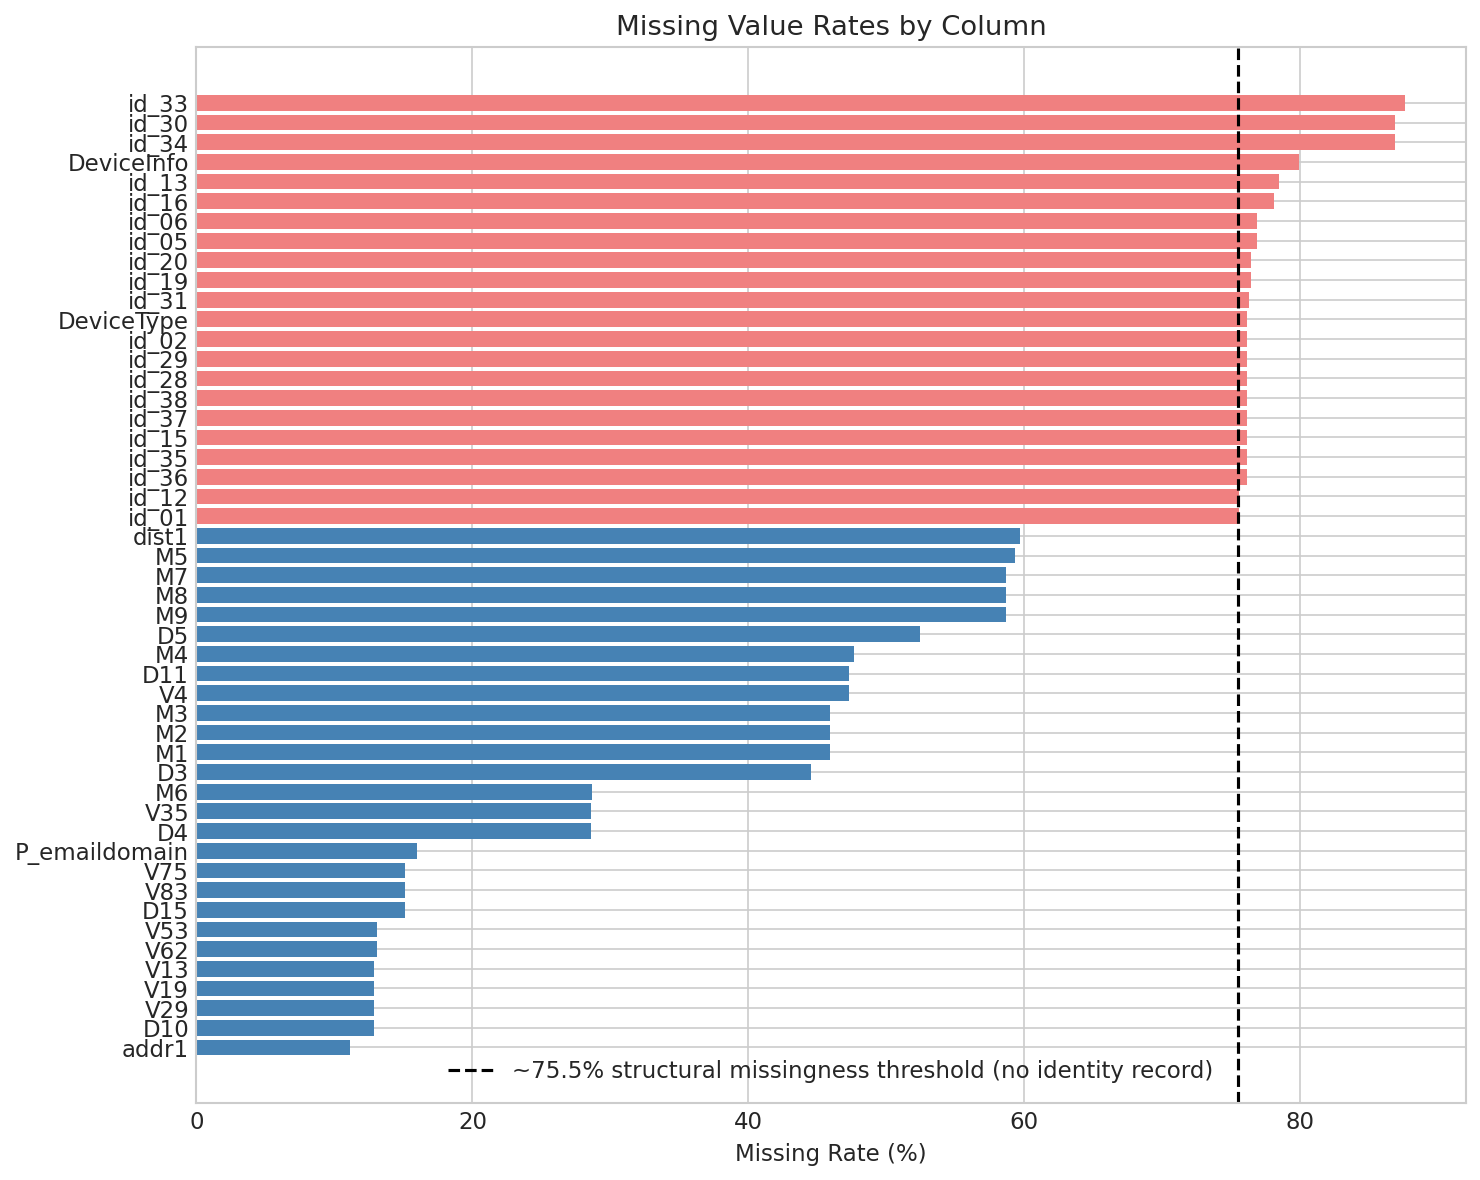

In [126]:
## Missing values

missing_rates = df.isnull().mean().sort_values(ascending=False)
missing_rates_identity = missing_rates[missing_rates >= 0.755]
missing_rates_transaction = missing_rates[(missing_rates < 0.755) & (missing_rates > 0.05)]

plt.figure(figsize=(10, 8))
plt.barh(missing_rates_identity.index, missing_rates_identity.values * 100, color="lightcoral")
plt.barh(missing_rates_transaction.index, missing_rates_transaction.values * 100, color="steelblue")
plt.xlabel("Missing Rate (%)")
plt.title("Missing Value Rates by Column")
plt.axvline(x=75.5, color="black", linestyle="--", label="~75.5% structural missingness threshold (no identity record)")
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.savefig("Report/figures/missing_values.png", bbox_inches="tight")
plt.show()

The missing value distribution reveals two distinct patterns. Columns below the 75.5% threshold have genuine partial missingness, the D, M and some V columns are simply not available for all transactions. Columns above the threshold are identity features that are structurally missing, approximately 75.5% of transactions have no associated identity record, meaning these columns are absent by design rather than data quality issues. Crucially, this missingness is itself informative, a transaction with no identity record behaves differently from one with full identity information.

Next, I look at class imbalance between fraud and normal transactions

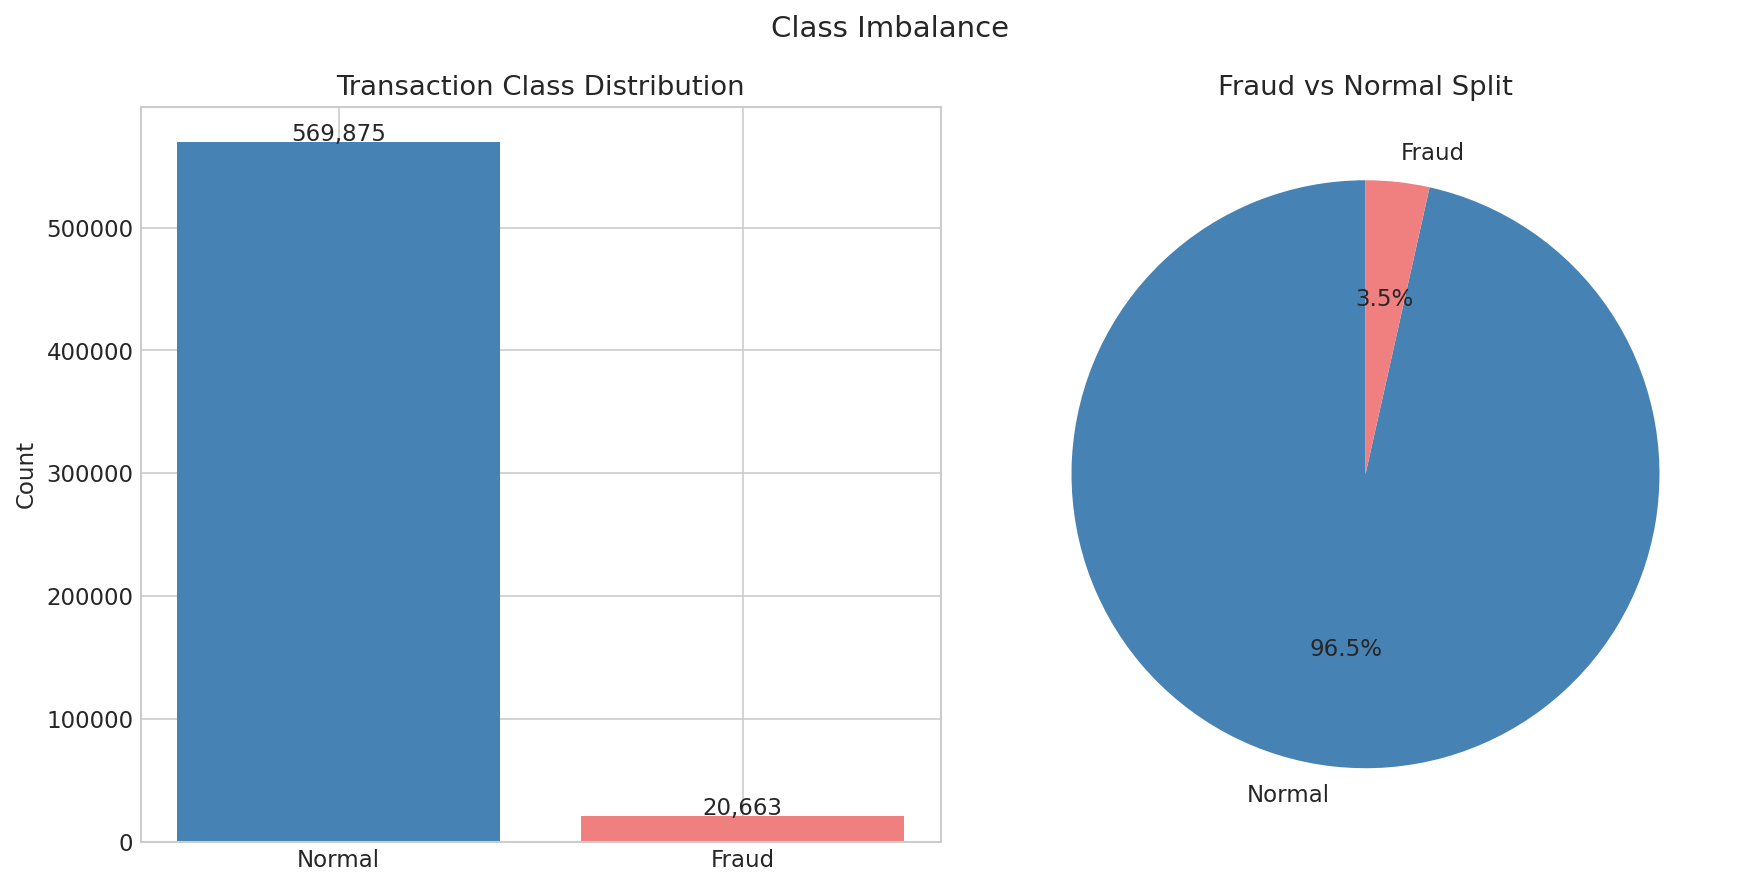

In [87]:
## Class Imbalance

fraud_counts = df["isFraud"].value_counts()
labels = ["Normal", "Fraud"]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Bar chart
axes[0].bar(labels, fraud_counts.values, color=["steelblue", "lightcoral"])
axes[0].set_title("Transaction Class Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 1000, f"{v:,}", ha="center")

# Pie chart
axes[1].pie(fraud_counts.values, labels=labels, colors=["steelblue", "lightcoral"],
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Fraud vs Normal Split")

plt.suptitle("Class Imbalance", fontsize=14)
plt.tight_layout()
plt.savefig("Report/figures/class_imbalance.png",bbox_inches="tight")
plt.show()

The dataset is heavily imbalanced with only 3.5% fraudulent transactions, making this a challenging detection problem and motivating my unsupervised approach as a supervised model would need careful handling of this imbalance.

Next, I look at TransactionAmt (log-transformed) disribution and box-plot

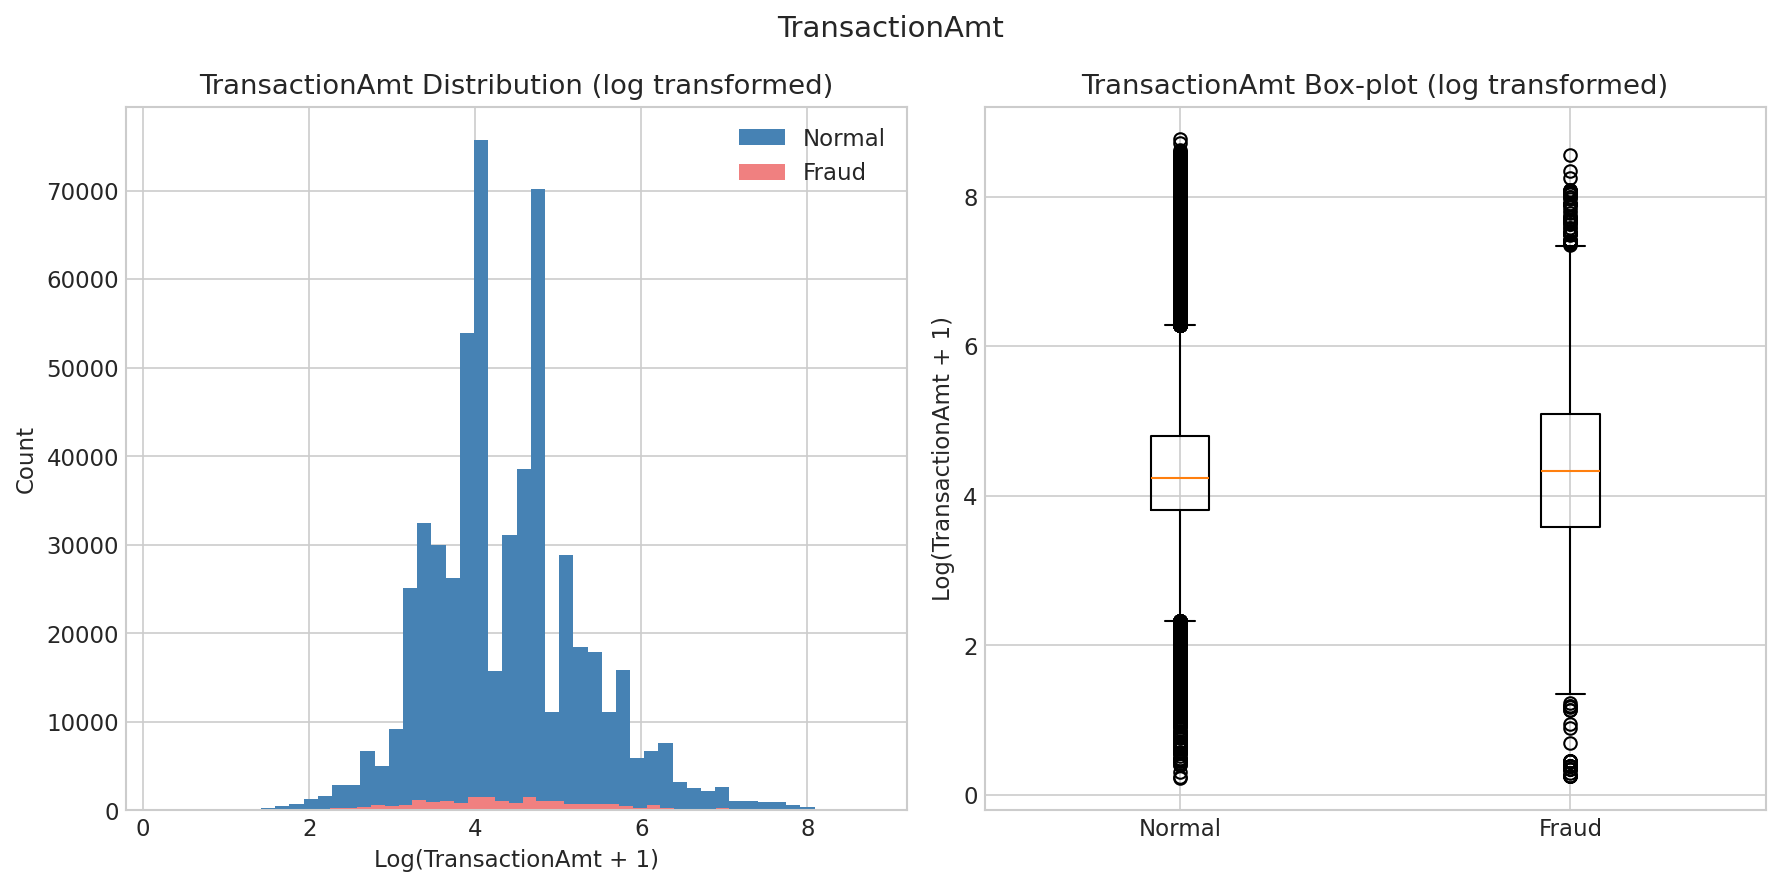

In [88]:
## Distribution and Box-plot

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# TransactionAmt distribution - fraud vs normal
normal = df[df["isFraud"] == 0]["TransactionAmt"]
fraud = df[df["isFraud"] == 1]["TransactionAmt"]
axes[0].hist(normal, bins=50, alpha=1.0, label="Normal", color="steelblue")
axes[0].hist(fraud, bins=50, alpha=1.0, label="Fraud", color="lightcoral")
axes[0].set_title("TransactionAmt Distribution (log transformed)")
axes[0].set_xlabel("Log(TransactionAmt + 1)")
axes[0].set_ylabel("Count")
axes[0].legend()

# TransactionAmt Box-plot

axes[1].boxplot([normal, fraud], tick_labels = ["Normal","Fraud"])
axes[1].set_title("TransactionAmt Box-plot (log transformed)")
axes[1].set_ylabel("Log(TransactionAmt + 1)")
plt.suptitle("TransactionAmt", fontsize=14)
plt.tight_layout()
plt.savefig("Report/figures/TransactionAmt.png",bbox_inches="tight")
plt.show()

Transaction amounts for both normal and fraudulent transactions are broadly similar in median and interquartile range, suggesting amount alone is not a strong discriminator. However the histogram reveals a key difference: normal transactions cluster tightly around log(TransactionAmt) ≈ 4 (roughly 50-100 dollars) with a clear multimodal pattern, while fraud transactions are more uniformly spread across the full range. Fraud transactions also show more low-value outliers in the box plot, consistent with card testing behavior where fraudsters make small test purchases before attempting larger ones.

>Note: there is an extreme outlier (two identical values) in the case of normal trasnactions, this was fixed in the cleaning process.

Next, I look at fraud rate compared to total number of transaction grouped by hours and days of the week

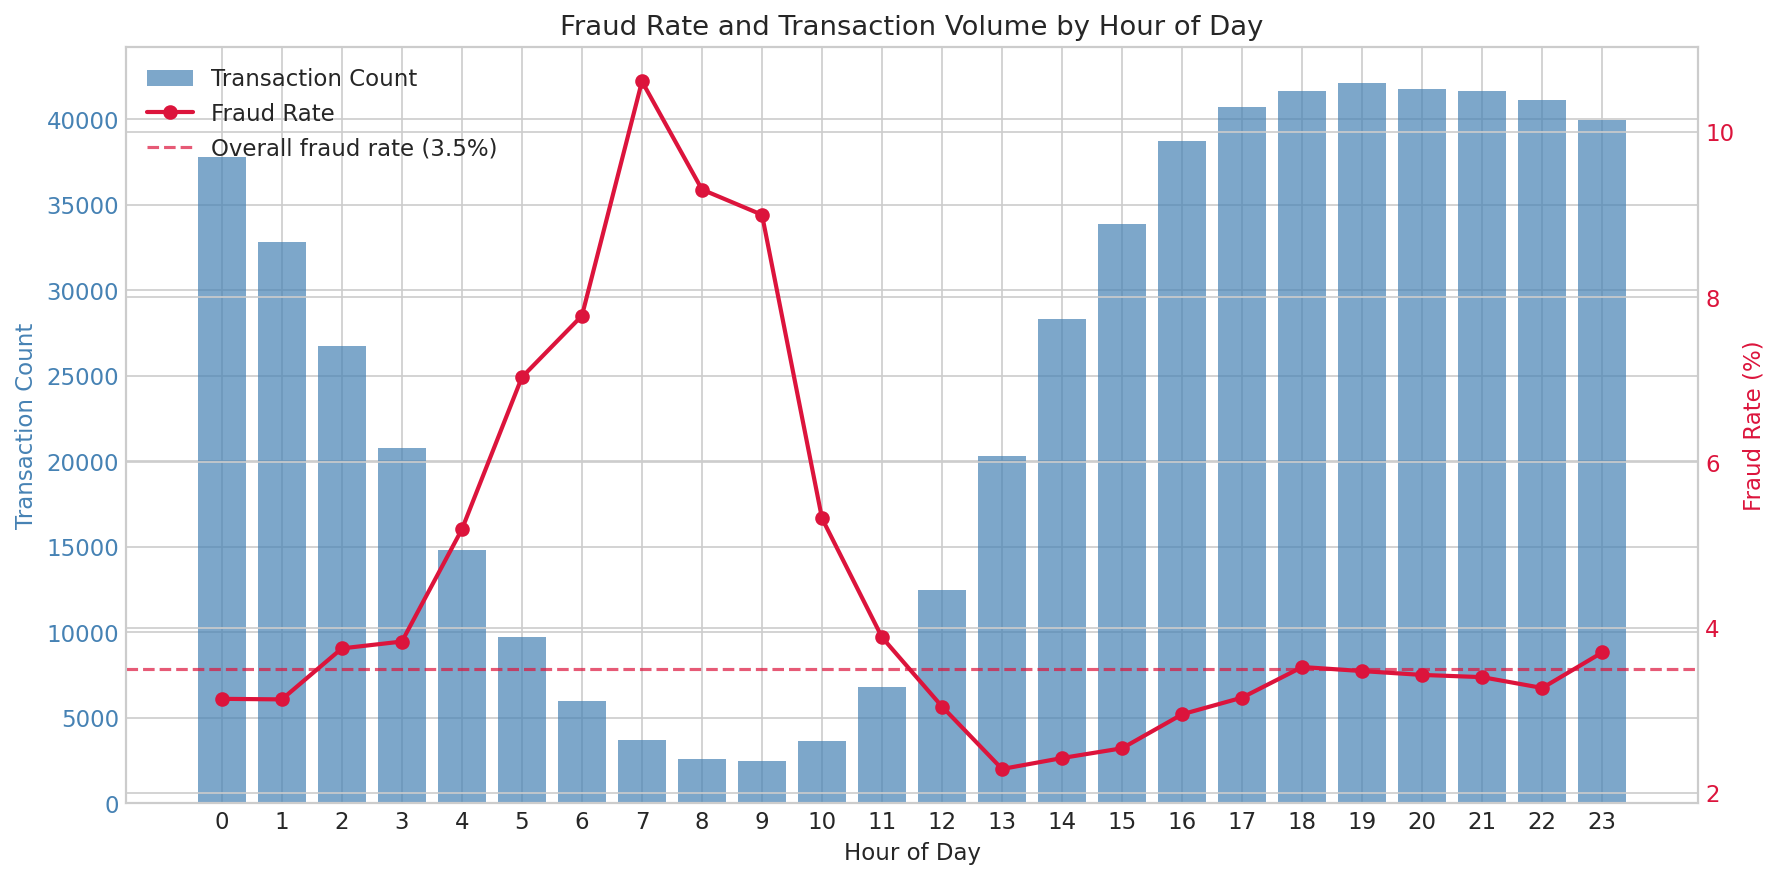

In [101]:
## Fraud by hours 

hourly_fraud = df.groupby("hour")["isFraud"].mean() * 100
hourly_count = df.groupby("hour")["isFraud"].count()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for transaction count on primary axis
ax1.bar(hourly_count.index, hourly_count.values, color="steelblue", alpha=0.7, label="Transaction Count")
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Transaction Count", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_xticks(range(0, 24))

# Fraud rate line on secondary axis
ax2 = ax1.twinx()
ax2.plot(hourly_fraud.index, hourly_fraud.values, color="crimson", marker="o", linewidth=2, label="Fraud Rate")
ax2.axhline(y=df["isFraud"].mean() * 100, color="crimson", linestyle="--", alpha=0.7, 
            label=f"Overall fraud rate ({df["isFraud"].mean()*100:.1f}%)")
ax2.set_ylabel("Fraud Rate (%)", color="crimson")
ax2.tick_params(axis="y", labelcolor="crimson")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Fraud Rate and Transaction Volume by Hour of Day")
plt.tight_layout()
plt.savefig("Report/figures/hourly_fraud.png", bbox_inches="tight")
plt.show()

Fraud rate peaks sharply at hour 7 (~10.5%), nearly 3x the overall average of 3.5%, despite relatively low transaction volume. This inverse relationship between volume and fraud rate is a classic pattern: fraudsters exploit low-traffic periods when anomalous behavior is less likely to trigger automated alerts. Fraud rate drops significantly during peak business hours (13:00-16:00) before rising again in the evening.

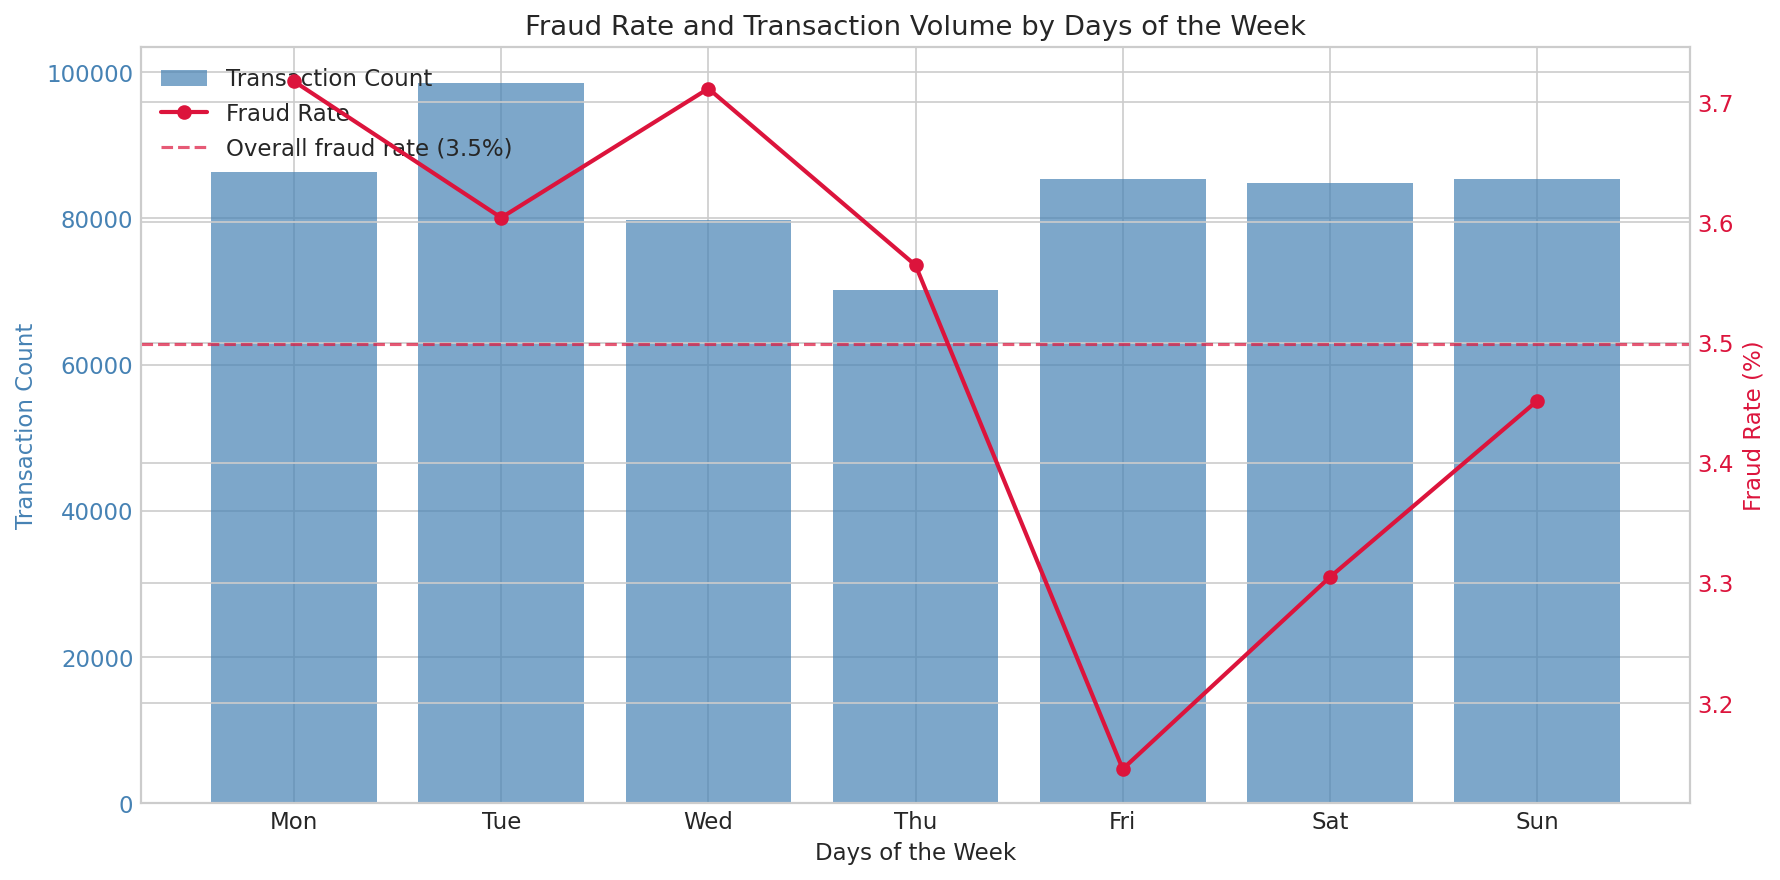

In [112]:
## Fraud by days of the week 

day_fraud = df.groupby("day_of_week")["isFraud"].mean() * 100
day_count = df.groupby("day_of_week")["isFraud"].count()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for transaction count on primary axis
ax1.bar(day_count.index, day_count.values, color="steelblue", alpha=0.7, label="Transaction Count")
ax1.set_xlabel("Days of the Week")
ax1.set_ylabel("Transaction Count", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_xticks(range(7))
ax1.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

# Fraud rate line on secondary axis
ax2 = ax1.twinx()
ax2.plot(day_fraud.index, day_fraud.values, color="crimson", marker="o", linewidth=2, label="Fraud Rate")
ax2.axhline(y=df["isFraud"].mean() * 100, color="crimson", linestyle="--", alpha=0.7, 
            label=f"Overall fraud rate ({df["isFraud"].mean()*100:.1f}%)")
ax2.set_ylabel("Fraud Rate (%)", color="crimson")
ax2.tick_params(axis="y", labelcolor="crimson")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Fraud Rate and Transaction Volume by Days of the Week")
plt.tight_layout()
plt.savefig("Report/figures/day_fraud.png", bbox_inches="tight")
plt.show()

Fraud rate varies moderately across days of the week, peaking between Monday and wednesday and dropping sharply on Friday before recovering over the weekend. Transaction volume remains relatively stable across all days, suggesting the day-of-week fraud pattern is behavioral rather than volume-driven.

Next, I look at the ProductCD column.

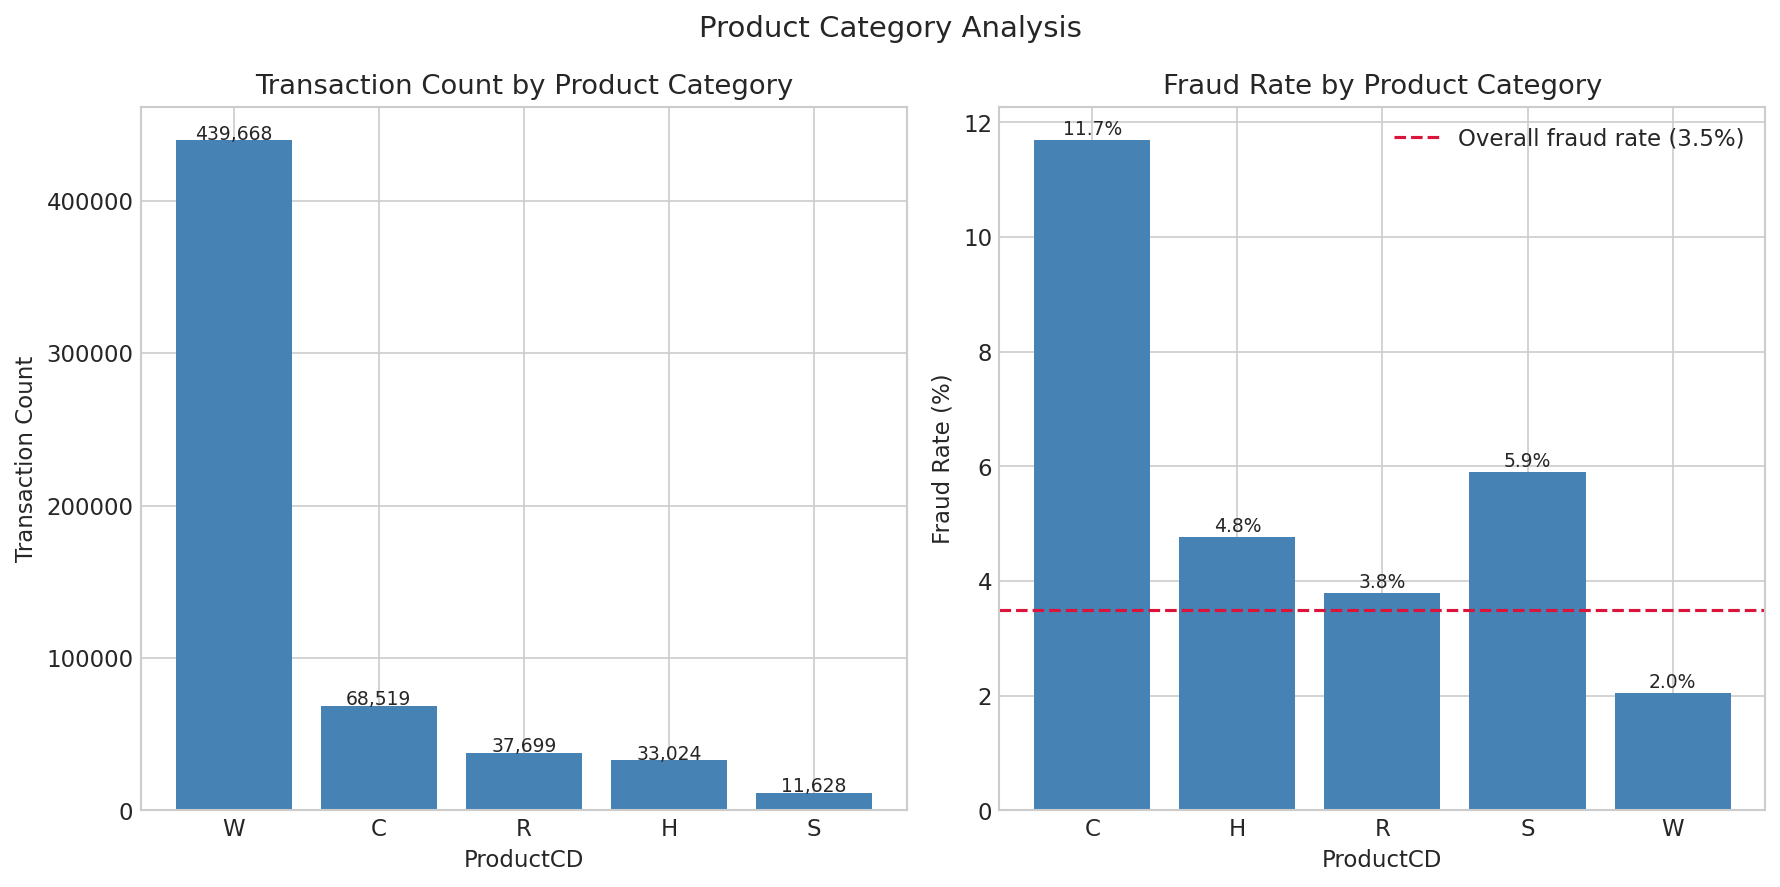

In [120]:
## ProductCD distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

product_count = df.groupby("ProductCD")["isFraud"].count().sort_values(ascending=False)
product_fraud = df.groupby("ProductCD")["isFraud"].mean() * 100

# Transaction count per ProductCD
axes[0].bar(product_count.index, product_count.values, color="steelblue")
axes[0].set_title("Transaction Count by Product Category")
axes[0].set_xlabel("ProductCD")
axes[0].set_ylabel("Transaction Count")
for i, v in enumerate(product_count.values):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontsize=9)

# Fraud rate per ProductCD
axes[1].bar(product_fraud.index, product_fraud.values, color="steelblue")
axes[1].axhline(y=df["isFraud"].mean() * 100, color="crimson", linestyle="--",
                label=f"Overall fraud rate ({df["isFraud"].mean()*100:.1f}%)")
axes[1].set_title("Fraud Rate by Product Category")
axes[1].set_xlabel("ProductCD")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].legend()
for i, v in enumerate(product_fraud.values):
    axes[1].text(i, v + 0.1, f"{v:.1f}%", ha="center", fontsize=9)

plt.suptitle("Product Category Analysis", fontsize=14)
plt.tight_layout()
plt.savefig("Report/figures/product_fraud.png", bbox_inches="tight")
plt.show()

Product category C has the highest fraud rate at 11.7%, more than 3x the overall average of 3.5%, despite being the second most common transaction type with 68,519 transactions. Product W dominates transaction volume (439,668 transactions, 74% of all transactions) but has the lowest fraud rate at just 2.0%, suggesting fraudsters avoid high-volume categories where anomalies are more easily detected. Product S has an elevated fraud rate of 5.9% despite very low volume (11,628 transactions), making it a high-risk low-volume category worth monitoring closely.

Next, I look at relation between fraud and email domains.

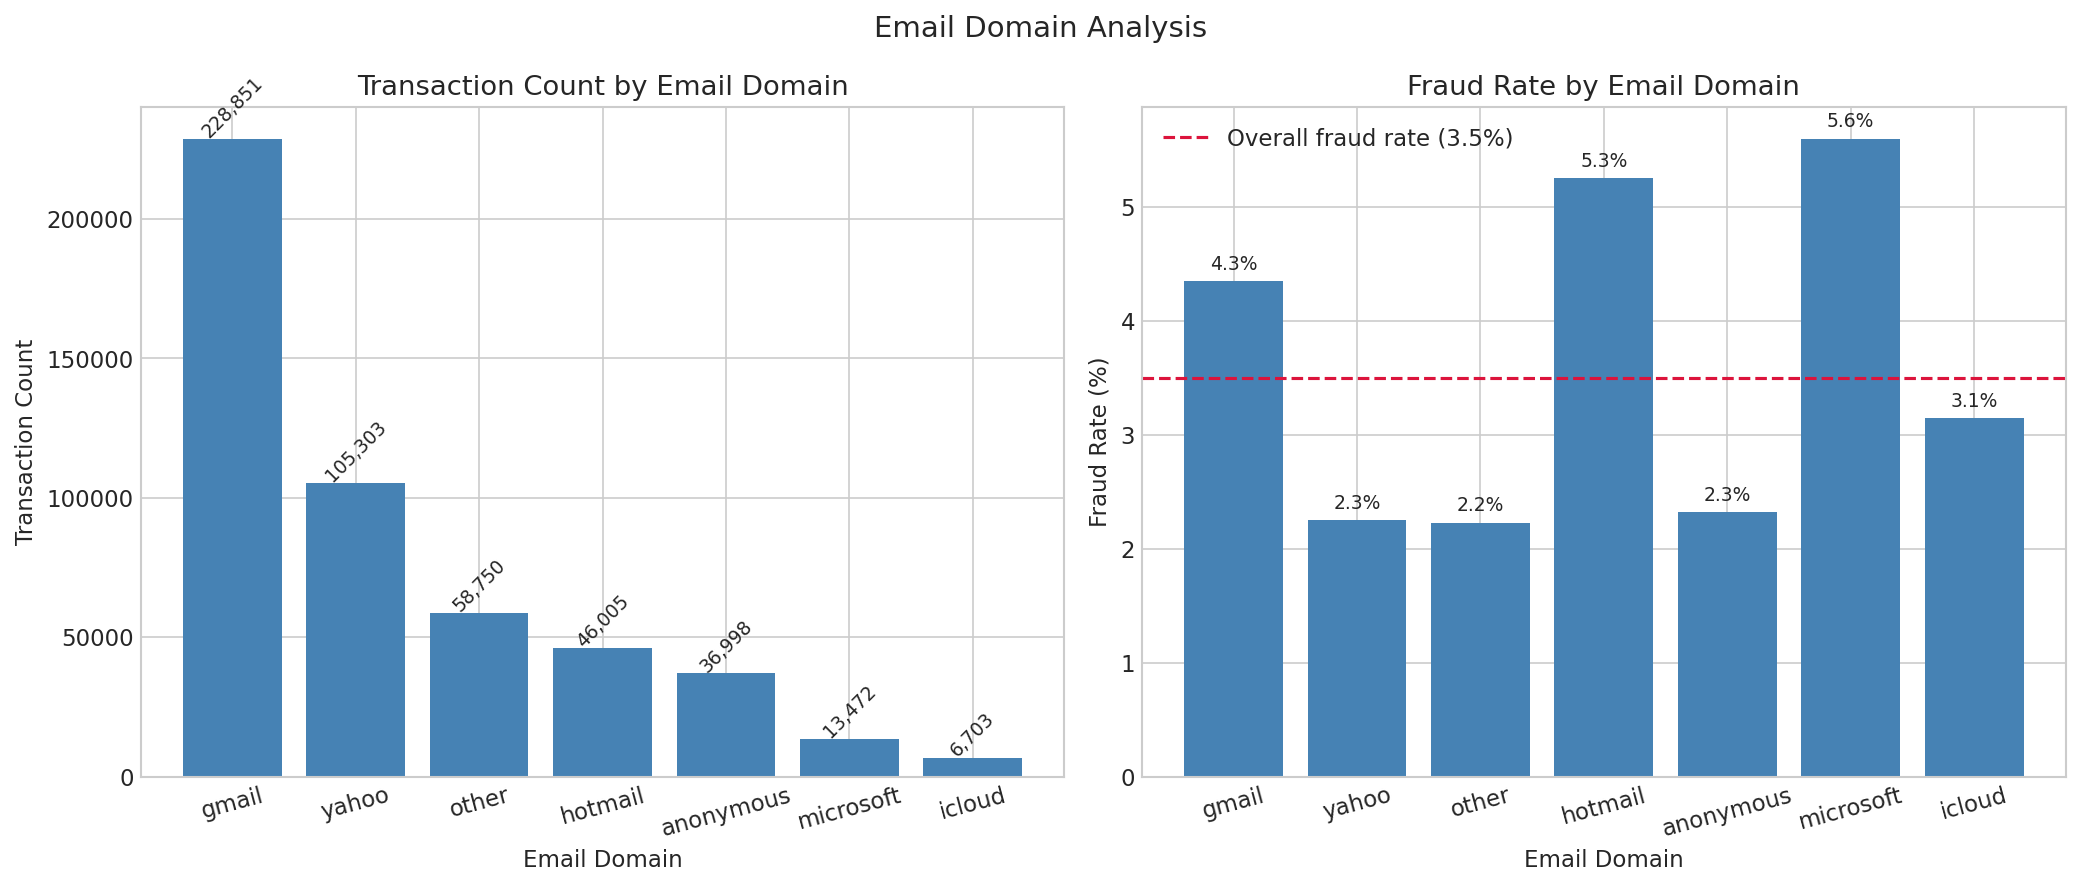

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

email_count = df.groupby("P_emaildomain")["isFraud"].count().sort_values(ascending=False)
email_fraud = df.groupby("P_emaildomain")["isFraud"].mean() * 100
email_fraud = email_fraud.reindex(email_count.index)  # same order as count

# Transaction count per email domain
axes[0].bar(email_count.index, email_count.values, color="steelblue")
axes[0].set_title("Transaction Count by Email Domain")
axes[0].set_xlabel("Email Domain")
axes[0].set_ylabel("Transaction Count")
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(email_count.values):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontsize=9, rotation=45)

# Fraud rate per email domain
axes[1].bar(email_fraud.index, email_fraud.values, color="steelblue")
axes[1].axhline(y=df["isFraud"].mean() * 100, color="crimson", linestyle="--",
                label=f"Overall fraud rate ({df["isFraud"].mean()*100:.1f}%)")
axes[1].set_title("Fraud Rate by Email Domain")
axes[1].set_xlabel("Email Domain")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()
for i, v in enumerate(email_fraud.values):
    axes[1].text(i, v + 0.1, f"{v:.1f}%", ha="center", fontsize=9)

plt.suptitle("Email Domain Analysis", fontsize=14)
plt.tight_layout()
plt.savefig("Report/figures/email_fraud.png", bbox_inches="tight")
plt.show()

Microsoft and Hotmail email domains show the highest fraud rates at 5.6% and 5.3% respectively, both significantly above the 3.5% average. Interestingly, anonymous.com which might be expected to correlate with fraud shows a relatively low rate of 2.3%, suggesting that truly anonymous transactions are not necessarily more fraudulent. Gmail dominates transaction volume with 228,851 transactions and a moderate fraud rate of 4.3%, while Yahoo and 'other' domains show the lowest fraud rates at around 2.2-2.3%.

Next, I look into Device related information

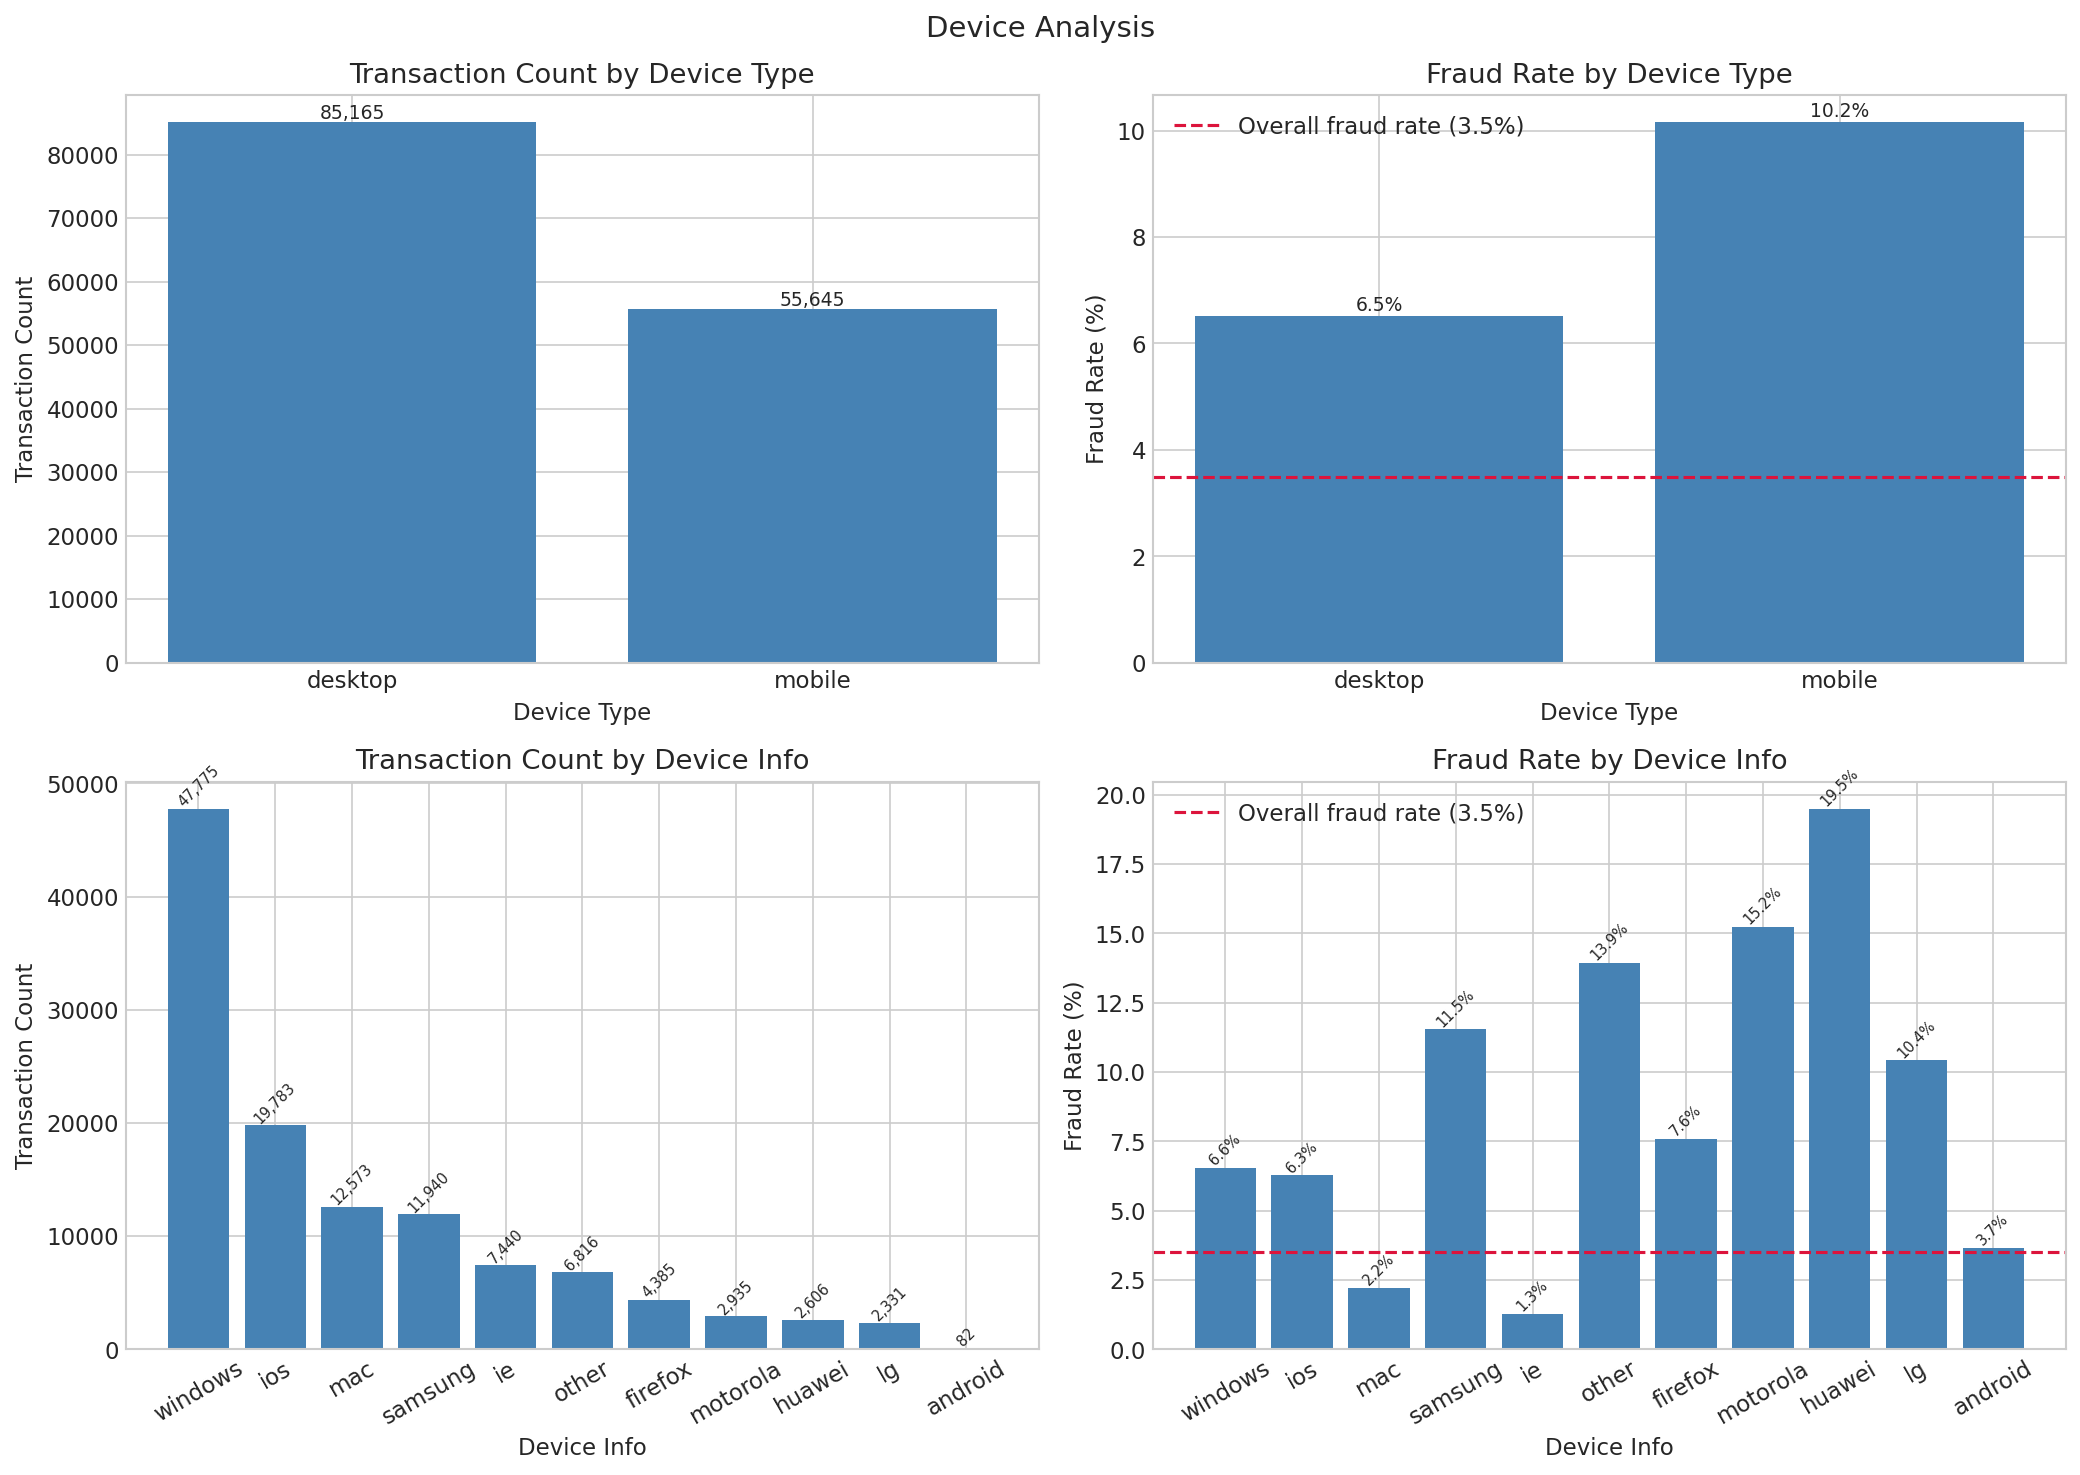

In [125]:
## Device related info distribution

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

device_count = df.groupby("DeviceType")["isFraud"].count().sort_values(ascending=False)
device_fraud = df.groupby("DeviceType")["isFraud"].mean() * 100
device_fraud = device_fraud.reindex(device_count.index)

info_count = df.groupby("DeviceInfo")["isFraud"].count().sort_values(ascending=False)
info_fraud = df.groupby("DeviceInfo")["isFraud"].mean() * 100
info_fraud = info_fraud.reindex(info_count.index)

overall_fraud = df["isFraud"].mean() * 100

# Top left - Transaction count by DeviceType
axes[0, 0].bar(device_count.index, device_count.values, color="steelblue")
axes[0, 0].set_title("Transaction Count by Device Type")
axes[0, 0].set_xlabel("Device Type")
axes[0, 0].set_ylabel("Transaction Count")
for i, v in enumerate(device_count.values):
    axes[0, 0].text(i, v + 500, f"{v:,}", ha="center", fontsize=9)

# Top right - Fraud rate by DeviceType
axes[0, 1].bar(device_fraud.index, device_fraud.values, color="steelblue")
axes[0, 1].axhline(y=overall_fraud, color="crimson", linestyle="--",
                   label=f"Overall fraud rate ({overall_fraud:.1f}%)")
axes[0, 1].set_title("Fraud Rate by Device Type")
axes[0, 1].set_xlabel("Device Type")
axes[0, 1].set_ylabel("Fraud Rate (%)")
axes[0, 1].legend()
for i, v in enumerate(device_fraud.values):
    axes[0, 1].text(i, v + 0.1, f"{v:.1f}%", ha="center", fontsize=9)

# Bottom left - Transaction count by DeviceInfo
axes[1, 0].bar(info_count.index, info_count.values, color="steelblue")
axes[1, 0].set_title("Transaction Count by Device Info")
axes[1, 0].set_xlabel("Device Info")
axes[1, 0].set_ylabel("Transaction Count")
axes[1, 0].tick_params(axis="x", rotation=30)
for i, v in enumerate(info_count.values):
    axes[1, 0].text(i, v + 200, f"{v:,}", ha="center", fontsize=7, rotation=45)

# Bottom right - Fraud rate by DeviceInfo
axes[1, 1].bar(info_fraud.index, info_fraud.values, color="steelblue")
axes[1, 1].axhline(y=overall_fraud, color="crimson", linestyle="--",
                   label=f"Overall fraud rate ({overall_fraud:.1f}%)")
axes[1, 1].set_title("Fraud Rate by Device Info")
axes[1, 1].set_xlabel("Device Info")
axes[1, 1].set_ylabel("Fraud Rate (%)")
axes[1, 1].tick_params(axis="x", rotation=30)
axes[1, 1].legend()
for i, v in enumerate(info_fraud.values):
    axes[1, 1].text(i, v + 0.1, f"{v:.1f}%", ha="center", fontsize=7, rotation=45)

plt.suptitle("Device Analysis", fontsize=14)
plt.tight_layout()
plt.savefig("Report/figures/device_fraud.png", dpi=150, bbox_inches="tight")
plt.show()

Mobile transactions have a significantly higher fraud rate (10.2%) compared to desktop (6.5%), both well above the overall average of 3.5%. This suggests mobile transactions carry inherently higher fraud risk, possibly due to weaker authentication or easier card-not-present fraud on mobile platforms.
At the device level, Huawei devices show a striking fraud rate of 19.5%, nearly 6x the overall average, despite relatively low transaction volume (2,606 transactions). Motorola (15.2%) and 'other' devices (13.9%) also show elevated rates. In contrast, Samsung (2.2%), Android generic (3.7%) and iOS (2.2%) devices show fraud rates at or below average.
The high fraud rate for Huawei and Motorola likely reflects geographic or demographic factors rather than device-specific vulnerabilities, these brands are more common in regions with higher fraud rates in this dataset.

## Pre-processing

---

Now, with EDA done, I move onto pre-processing of the data to pass it to PyTorch and Isolation Forest model

In [132]:
## Reading the full cleaned dataset

df = pd.read_csv("data/processed/full_clean_dataset.csv")

Before preprocessing, the data is split into training and test sets. This order is critical: fitting the preprocessing pipeline (imputation, scaling, encoding) must happen on the training set only.

If we fit the preprocessor on the full dataset before splitting, the median values used for imputation and the scaling parameters would be calculated using test set data. This means the model indirectly 'sees' the test set during training, a form of data leakage that artificially inflates performance metrics.

The correct order is:

1. Split first
2. Fit preprocessor on training data only
3. Transform both train and test using training statistics

Additionally, since fraud patterns evolve over time, the split is done chronologically rather than randomly. The model is trained on earlier transactions and evaluated on later ones, directly simulating real deployment conditions where the model always predicts on future unseen transactions.

In [133]:
df = df.sort_values(by = "TransactionDT") # sorting according to TransactionDT

# Splitting the data chronologically

X = df.drop(columns=["isFraud","TransactionDT"]) 
y = df["isFraud"]
train_X ,test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=26, shuffle = False)

In [134]:
## Fraud rate in each split

print("training set:",train_y.value_counts(normalize=True),"\ntesting set:",test_y.value_counts(normalize=True))

training set: isFraud
0    0.964865
1    0.035135
Name: proportion, dtype: float64 
testing set: isFraud
0    0.965591
1    0.034409
Name: proportion, dtype: float64


The fraud rate in both the test and train set is equivlent ~3.5%

In [135]:
## getting the normal transactions as unsupervised models only train on the normal transactions

train_X_normal = train_X[train_y == 0]

As already stated above, The V-columns do harm to the VAE but help the Isolation Forest, therefore I have made to pre-processing pipeline:

1. preprocessor_VAE: Without V-columns
2. preprocessor_Iso: With V-columns

In [136]:
## Dropping V-columns from dataset for VAE

v_col = [c for c in df.columns if c.startswith("V")]

#VAE
train_X_normal_VAE = train_X_normal.drop(columns=v_col)
test_X_VAE = test_X.drop(columns=v_col)

#Iso
train_X_normal_Iso = train_X_normal
test_X_Iso = test_X

In [137]:
## Seperate out the numerical and categorical columns

#VAE
num_col_VAE = train_X_normal_VAE.select_dtypes(include = ["number"]).columns.tolist()
cat_col_VAE = train_X_normal_VAE.select_dtypes(include=["object"]).columns.tolist()

#Iso
num_col_Iso = train_X_normal_Iso.select_dtypes(include = ["number"]).columns.tolist()
cat_col_Iso = train_X_normal_Iso.select_dtypes(include=["object"]).columns.tolist()

In [139]:
## setting up the pipelines

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

#VAE
preprocessor_VAE = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_col_VAE),
    ('cat', cat_pipeline, cat_col_VAE)
])

#Iso
preprocessor_Iso = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_col_Iso),
    ('cat', cat_pipeline, cat_col_Iso)
])

In [140]:
## Fitting the columntransformer to the training set

#VAE
train_processed_VAE = preprocessor_VAE.fit_transform(train_X_normal_VAE)
#Save VAE pipeline
joblib.dump(preprocessor_VAE,"model/transform_rule_VAE.pkl")

#Iso
train_processed_Iso = preprocessor_Iso.fit_transform(train_X_normal_Iso)
#Save Iso pipeline
joblib.dump(preprocessor_Iso,"model/transform_rule_Iso.pkl")

['model/transform_rule_Iso.pkl']

Note that PyTorch accepts data as float32 so converting the encoded matrix into float32 is necessary. Eventhough, this is not necessary for Isolation Forest, I do it for uniformity.

In [141]:
## Converting data type to float32 and transforming the test data as well

#VAE
train_processed_VAE = train_processed_VAE.astype("float32")
test_processed_VAE = preprocessor_VAE.transform(test_X_VAE).astype("float32")

#Iso
train_processed_Iso = train_processed_Iso.astype("float32")
test_processed_Iso = preprocessor_Iso.transform(test_X_Iso).astype("float32")

In [142]:
## save the transformed data as a matrix

#VAE
np.save("data/processed/trainset_VAE.npy" ,train_processed_VAE)
np.save("data/processed/testset_VAE.npy" ,test_processed_VAE)

#Iso
np.save("data/processed/trainset_Iso.npy" ,train_processed_Iso)
np.save("data/processed/testset_Iso.npy" ,test_processed_Iso)

#testlabel needs to be stored only once
np.save("data/processed/testlabel.npy",test_y.values)

It is also important to save the encoded feature names for debugging.

In [146]:
## Save the feature list as well

#VAE
feature_list_VAE = preprocessor_VAE.get_feature_names_out()

#Iso
feature_list_Iso = preprocessor_Iso.get_feature_names_out()

# preparing dict to save everything together

feature_list_VAE = feature_list_VAE.tolist()
feature_list_Iso = feature_list_Iso.tolist()

feature_dic = {
    "Model_Name" : ["VAE","Iso"],
    "No. of rows" : [len(feature_list_VAE),len(feature_list_Iso)],
    "feature_name" : [feature_list_VAE,feature_list_Iso]
              }

In [149]:
## save feature name to a json file

with open("metadata/feature_name.json", "w") as f:
    json.dump(feature_dic,f)

## Modelling

---

With pre-processing done, I move onto modelling. First I train the VAE and then move onto the Isolation Forest.

---

### VAE

To efficiently load the preprocessed numpy arrays into PyTorch, I implement a custom Dataset class by subclassing torch.utils.data.Dataset. This requires overwriting three methods: __init__ for loading data, __len__ for returning the dataset size, and __getitem__ for returning individual samples by index.
from_numpy is used instead of torch.tensor to load the arrays - this avoids creating a copy of the data in memory, which is important given the size of the dataset.
The DataLoader wraps the Dataset and handles batching automatically. shuffle=True is used for the training DataLoader to prevent the model from learning any ordering patterns in the data. shuffle=False is used for the test DataLoader to ensure test results remain in a consistent order aligned with the test labels.

In [3]:
## Dataset class

class Frauddataset(Dataset):
    
    def __init__(self, featuresfile, labelfile = None):
        features =  np.load(featuresfile)
        self.x = from_numpy(features)
        del features
        
        if labelfile is not None:
            label = np.load(labelfile)
            self.y = from_numpy(label).float()
            del label
            
    def __len__(self):
        return len(self.x)
    
    def __getitem__(self,idx):
        
        features = self.x[idx]
        
        if hasattr(self, 'y') and self.y is not None:
            return features, self.y[idx]
    
        return features
            
        

In [4]:
## Load the data

train_dataset = Frauddataset(featuresfile = "data/processed/trainset_VAE.npy")
print(f"Loaded {len(train_dataset)} rows with {train_dataset.x.shape[1]} features.")

test_dataset = Frauddataset(featuresfile = "data/processed/testset_VAE.npy", labelfile = "data/processed/testlabel.npy")
print(f"Loaded {len(test_dataset)} rows with {test_dataset.x.shape[1]} features and {test_dataset.y.shape[0]} labels.")

Loaded 455831 rows with 147 features.
Loaded 118108 rows with 147 features and 118108 labels.


In [5]:
## Batching the data using the dataloader.

train_dataloader = DataLoader(train_dataset, batch_size=2048, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=2048, shuffle=False)

In [5]:
## Ensuring dataloader works as expected

train_feature = next(iter(train_dataloader))
print(f"Training batch shape: {len(train_feature)}")

test_feature, test_label = next(iter(test_dataloader))
print(f"Test batch shape: {len(test_feature)} \nTest label batch shape: {len(test_label)}")

Training batch shape: 2048
Test batch shape: 2048 
Test label batch shape: 2048


The Variational Autoencoder (VAE) consists of an encoder that compresses the input into a latent representation, and a decoder that reconstructs the input from that representation. The key idea for anomaly detection is that the VAE is trained exclusively on normal transactions, fraudulent transactions, being unlike anything seen during training, produce higher reconstruction errors and are flagged as anomalies.

The encoder follows a progressive compression path:

- Input(147) → 64 → 32 → 16 → μ, log σ²(z_dim)

Rather than encoding directly to a fixed point, the encoder outputs two vectors: μ (mean) and log σ² (log variance), which define a probability distribution in the latent space. A sample z is drawn from this distribution via the reparameterization trick: z = μ + ε · σ, where ε ~ N(0,1). This makes the latent space continuous and smooth, encouraging the model to learn generalizable representations of normal transactions rather than memorizing individual ones.

The decoder mirrors the encoder symmetrically:

- z_dim → 16 → 32 → 64 → Output(147)

LeakyReLU is used as the activation function instead of standard ReLU. ReLU suffers from the dying neuron problem: neurons that receive negative inputs output zero and stop contributing to learning. LeakyReLU allows a small gradient for negative inputs, keeping all neurons active throughout training.

In [6]:
## VAE class function

class MyVAE(nn.Module):
    
    def __init__(self,input_dim, z_dim):
        super().__init__()
        
        ## Encoding architecture
        
        self.encode_arc = nn.Sequential(
                            nn.Linear(input_dim,64),
                            nn.LeakyReLU(),
                            nn.Linear(64,32),
                            nn.LeakyReLU(),
                            nn.Linear(32,16),
                            nn.LeakyReLU(),
        )
        
        self.mu_head = nn.Linear(16, z_dim)
        self.logvar_head = nn.Linear(16, z_dim)
        
        ## Decoding architecture
        
        self.decode_arc = nn.Sequential(
                            nn.Linear(z_dim, 16),
                            nn.ReLU(),
                            nn.Linear(16,32),
                            nn.ReLU(),
                            nn.Linear(32,64),
                            nn.ReLU(),
                            nn.Linear(64, input_dim)
        )
        
        
        
        
    def encode(self,x):
        h = self.encode_arc(x)
        return self.mu_head(h), self.logvar_head(h)
    
    def reparameterize(self, mu, logvar):
        sigma = torch.exp(0.5*logvar)
        epsilon = torch.randn_like(sigma)
        reparam = mu + epsilon*sigma
        return reparam
    
    def decode(self,z):
        h = self.decode_arc(z)
        return h
    
    def forward(self,x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu,logvar)
        reconstructed_x = self.decode(z)
        return reconstructed_x, mu, logvar

In [7]:
## Setting up the device as GPU if available

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


The VAE is trained by minimizing a loss function with two components:

Reconstruction Loss (MSE): measures how well the decoder reconstructs the original input from the latent representation. A lower reconstruction loss means the model has learned to accurately reproduce normal transaction patterns. Mean Squared Error is used, summed across all features and all samples in the batch.

KL Divergence Loss (KLD): regularizes the latent space by penalizing deviation from a standard normal distribution N(0,1). Without this term, the encoder could map each input to a completely separate region of the latent space with no overlap, making the latent space discontinuous and the reparameterization trick meaningless. The KLD term encourages the latent distributions to overlap, producing a smooth and structured latent space.

The total loss is:

Loss = Reconstruction Loss + β * KLD Loss

In [8]:
## Loss function

def vae_loss_function(reconstructed_x, x, mu, logvar, beta):
    
    recon_loss = nn.functional.mse_loss(reconstructed_x, x, reduction='sum')
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return recon_loss + beta*kld_loss

The training loop iterates over batches of normal transactions, passes them through the VAE, computes the loss, and updates the model weights via backpropagation. 

The Adam optimizer is used with a learning rate of 1e-3: Adam adapts the learning rate for each parameter individually, making it well suited for sparse and noisy tabular data.

A batch size of 2048 is used. Smaller batches produce noisier gradient estimates while larger batches reduce GPU memory efficiency.

In [9]:
## Training one epoch function

def train_1epoch(model,train_dataloader,optimizer,beta,device):
    
    model.train()
    
    train_loss = 0
    size = len(train_dataloader.dataset)
    
    for batch, x in enumerate(train_dataloader):
        x = x.to(device)
        optimizer.zero_grad()
        reconstructed_x, mu, logvar = model(x)
        loss = vae_loss_function(reconstructed_x, x, mu, logvar, beta)
        
       
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    Avg_loss = train_loss / size
    return Avg_loss

## Function to calculate AUC and AP per epoch

def AUROC_AP_1epcoh(model, test_dataloader, device):
    
    model.eval()
    reconstruction_errors = []
    all_labels = []
    
    with torch.no_grad():
        for X, y in test_dataloader:
            X = X.to(device)
            reconstructed, mu, logvar = model(X)
            errors = torch.mean((X - reconstructed) ** 2, dim=1)
            reconstruction_errors.extend(errors.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            
    reconstruction_errors = np.array(reconstruction_errors)
    all_labels = np.array(all_labels)
    
    auroc = roc_auc_score(all_labels, reconstruction_errors)
    ap = average_precision_score(all_labels, reconstruction_errors)
    
    return auroc, ap

### Experiment

---

Before training the final model, I conduct a systematic hyperparameter search to identify the optimal configuration. Rather than making arbitrary choices, I grid search over the three most impactful hyperparameters:
- β: controls the weight of the KLD term relative to reconstruction loss. Higher β forces stronger latent space regularization at the cost of reconstruction quality.
- z_dim: the dimensionality of the latent space. Controls how aggressively the encoder compresses the input.
- learning rate: controls the step size of gradient updates during training.
Each configuration is trained for 20 epochs, sufficient to compare relative performance without the computational cost of full training. The evaluation metric is Average Precision (AP), which is more informative than AUROC for heavily imbalanced datasets like this one (3.5% fraud rate).

In [99]:
## Training loop


# Parameters
epochs = 20
betas = [1.0, 2.0, 5.0]
z_dims = [3, 5, 10]
lrs = [1e-3, 5e-4, 1e-4]
input_dim = train_dataset.x.shape[1]

# Lists for storing result
parameter_dict = {"beta":[],"z_dim":[],"lr":[],"AUROC":[],"AP":[]}

for beta in betas:
    for z_dim in z_dims:
        for lr in lrs:
            
            # Initiating the model and setting up the optimizer
            torch.manual_seed(26)
            torch.cuda.manual_seed(26)
            np.random.seed(26) # setting seed for reproducibilty
            model = MyVAE(input_dim,z_dim).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            
            parameter_dict["beta"].append(beta)
            parameter_dict["z_dim"].append(z_dim)
            parameter_dict["lr"].append(lr)
            losses = []
            aurocs = []
            aps = []
            
            # training
            for epoch in range(epochs):
                avg_loss = train_1epoch(model,train_dataloader,optimizer,beta,device)
                auroc, ap = AUROC_AP_1epcoh(model, test_dataloader, device)
    
                losses.append(avg_loss)
                aurocs.append(auroc)
                aps.append(ap)
            
            parameter_dict["AUROC"].append(aurocs[19])
            parameter_dict["AP"].append(aps[19])
            print(f"Beta={beta} | z_dim={z_dim} | lr={lr} | AP: {aps[19]:.4f}")
result_grid = pd.DataFrame(parameter_dict)
pd.DataFrame(result_grid).to_csv('Report/results/grid_search.csv', index=False)

Beta=1.0 | z_dim=3 | lr=0.001 | AP: 0.0783
Beta=1.0 | z_dim=3 | lr=0.0005 | AP: 0.0796
Beta=1.0 | z_dim=3 | lr=0.0001 | AP: 0.0833
Beta=1.0 | z_dim=5 | lr=0.001 | AP: 0.0741
Beta=1.0 | z_dim=5 | lr=0.0005 | AP: 0.0768
Beta=1.0 | z_dim=5 | lr=0.0001 | AP: 0.0754
Beta=1.0 | z_dim=10 | lr=0.001 | AP: 0.0756
Beta=1.0 | z_dim=10 | lr=0.0005 | AP: 0.0751
Beta=1.0 | z_dim=10 | lr=0.0001 | AP: 0.0753
Beta=2.0 | z_dim=3 | lr=0.001 | AP: 0.0709
Beta=2.0 | z_dim=3 | lr=0.0005 | AP: 0.0764
Beta=2.0 | z_dim=3 | lr=0.0001 | AP: 0.0751
Beta=2.0 | z_dim=5 | lr=0.001 | AP: 0.0710
Beta=2.0 | z_dim=5 | lr=0.0005 | AP: 0.0720
Beta=2.0 | z_dim=5 | lr=0.0001 | AP: 0.0738
Beta=2.0 | z_dim=10 | lr=0.001 | AP: 0.0761
Beta=2.0 | z_dim=10 | lr=0.0005 | AP: 0.0749
Beta=2.0 | z_dim=10 | lr=0.0001 | AP: 0.0731
Beta=5.0 | z_dim=3 | lr=0.001 | AP: 0.0716
Beta=5.0 | z_dim=3 | lr=0.0005 | AP: 0.0709
Beta=5.0 | z_dim=3 | lr=0.0001 | AP: 0.0696
Beta=5.0 | z_dim=5 | lr=0.001 | AP: 0.0705
Beta=5.0 | z_dim=5 | lr=0.0005 | A

In [100]:
print("The result is of hyperparameter tunning is:")
result_grid.sort_values(by = ["AUROC","AP"], ascending=False)

The result is of hyperparameter tunning is:


,beta,z_dim,lr,AUROC,AP
2,1.0,3,0.0001,0.691750,0.083310
5,1.0,5,0.0001,0.690910,0.075375
8,1.0,10,0.0001,0.690546,0.075299
11,2.0,3,0.0001,0.688129,0.075110
14,2.0,5,0.0001,0.685114,0.073838
16,2.0,10,0.0005,0.681555,0.074892
17,2.0,10,0.0001,0.681170,0.073123
15,2.0,10,0.0010,0.678114,0.076119
24,5.0,10,0.0010,0.676837,0.071898
1,1.0,3,0.0005,0.674337,0.079579


The grid search results show that beta=1, z_dim=3 and lr=0.0001 is the optimal configuration, achieving AUROC ~0.69 and AP ~0.083.

Moerover, first, lr=0.0001 consistently outperforms higher learning rates across all β and z_dim combinations, slower gradient updates allow the model to converge more carefully to a stable latent representation of normal transactions rather than overshooting. Second, z_dim=3 more or less outperforms larger latent spaces, a tighter bottleneck forces the encoder to retain only the most essential patterns of normal behavior, making deviations more detectable. With larger z_dim values the decoder has enough capacity to reconstruct fraud transactions reasonably well, reducing the reconstruction error gap. Third, beta has somewhat minimal impact on performance, varying it across 1.0, 2.0 and 5.0 produces negligible differences, confirming that the reconstruction loss dominates the learning signal for this dataset and beta=1 is sufficient.

### Final Model

---

Based on the grid search results, the final model uses:
- Beta = 1
- z_dim = 3
- lr = 0.0001
- 50 epochs with best checkpoint saving (warmup of 5 epochs)

In [50]:
## Training loop

# Parameters
epochs = 50
beta = 1.0
z_dim = 3
lr = 0.0001
best_ap = 0
warmup_epochs = 5

# Initiating the model and setting up the optimizer
torch.manual_seed(26)
torch.cuda.manual_seed(26)
np.random.seed(26) # setting seed for reproducibilty
model = MyVAE(input_dim,z_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# list to store results
losses = []
aurocs = []
aps = []
            
# training
for epoch in range(epochs):
    avg_loss = train_1epoch(model,train_dataloader,optimizer,beta,device) # print statement is turned off
    auroc, ap = AUROC_AP_1epcoh(model, test_dataloader, device)
    
    losses.append(avg_loss)
    aurocs.append(auroc)
    aps.append(ap)
    
    if epoch >= warmup_epochs and ap > best_ap:
        best_ap = ap
        torch.save(model.state_dict(), "model/best_vae.pt")
        print(f"Epoch {epoch+1} | New best AP: {best_ap:.4f} - model saved")
    
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | AUROC: {auroc:.4f} | AP: {ap:.4f}")

# Save the arrays
np.save("Report/results/training_losses.npy", np.array(losses))
np.save("Report/results/training_aurocs.npy", np.array(aurocs))
np.save("Report/results/training_aps.npy", np.array(aps))

Epoch 1/50 | Loss: 50.0744 | AUROC: 0.6500 | AP: 0.0623
Epoch 2/50 | Loss: 38.0722 | AUROC: 0.6695 | AP: 0.0672
Epoch 3/50 | Loss: 33.9993 | AUROC: 0.6744 | AP: 0.0692
Epoch 4/50 | Loss: 32.0110 | AUROC: 0.6805 | AP: 0.0718
Epoch 5/50 | Loss: 30.7818 | AUROC: 0.6798 | AP: 0.0722
Epoch 6 | New best AP: 0.0727 - model saved
Epoch 6/50 | Loss: 30.3229 | AUROC: 0.6795 | AP: 0.0727
Epoch 7 | New best AP: 0.0742 - model saved
Epoch 7/50 | Loss: 29.8693 | AUROC: 0.6844 | AP: 0.0742
Epoch 8 | New best AP: 0.0755 - model saved
Epoch 8/50 | Loss: 29.1742 | AUROC: 0.6874 | AP: 0.0755
Epoch 9 | New best AP: 0.0767 - model saved
Epoch 9/50 | Loss: 28.6586 | AUROC: 0.6899 | AP: 0.0767
Epoch 10 | New best AP: 0.0780 - model saved
Epoch 10/50 | Loss: 28.0850 | AUROC: 0.6939 | AP: 0.0780
Epoch 11 | New best AP: 0.0785 - model saved
Epoch 11/50 | Loss: 27.4803 | AUROC: 0.6951 | AP: 0.0785
Epoch 12 | New best AP: 0.0790 - model saved
Epoch 12/50 | Loss: 26.9165 | AUROC: 0.6964 | AP: 0.0790
Epoch 13/50 | 

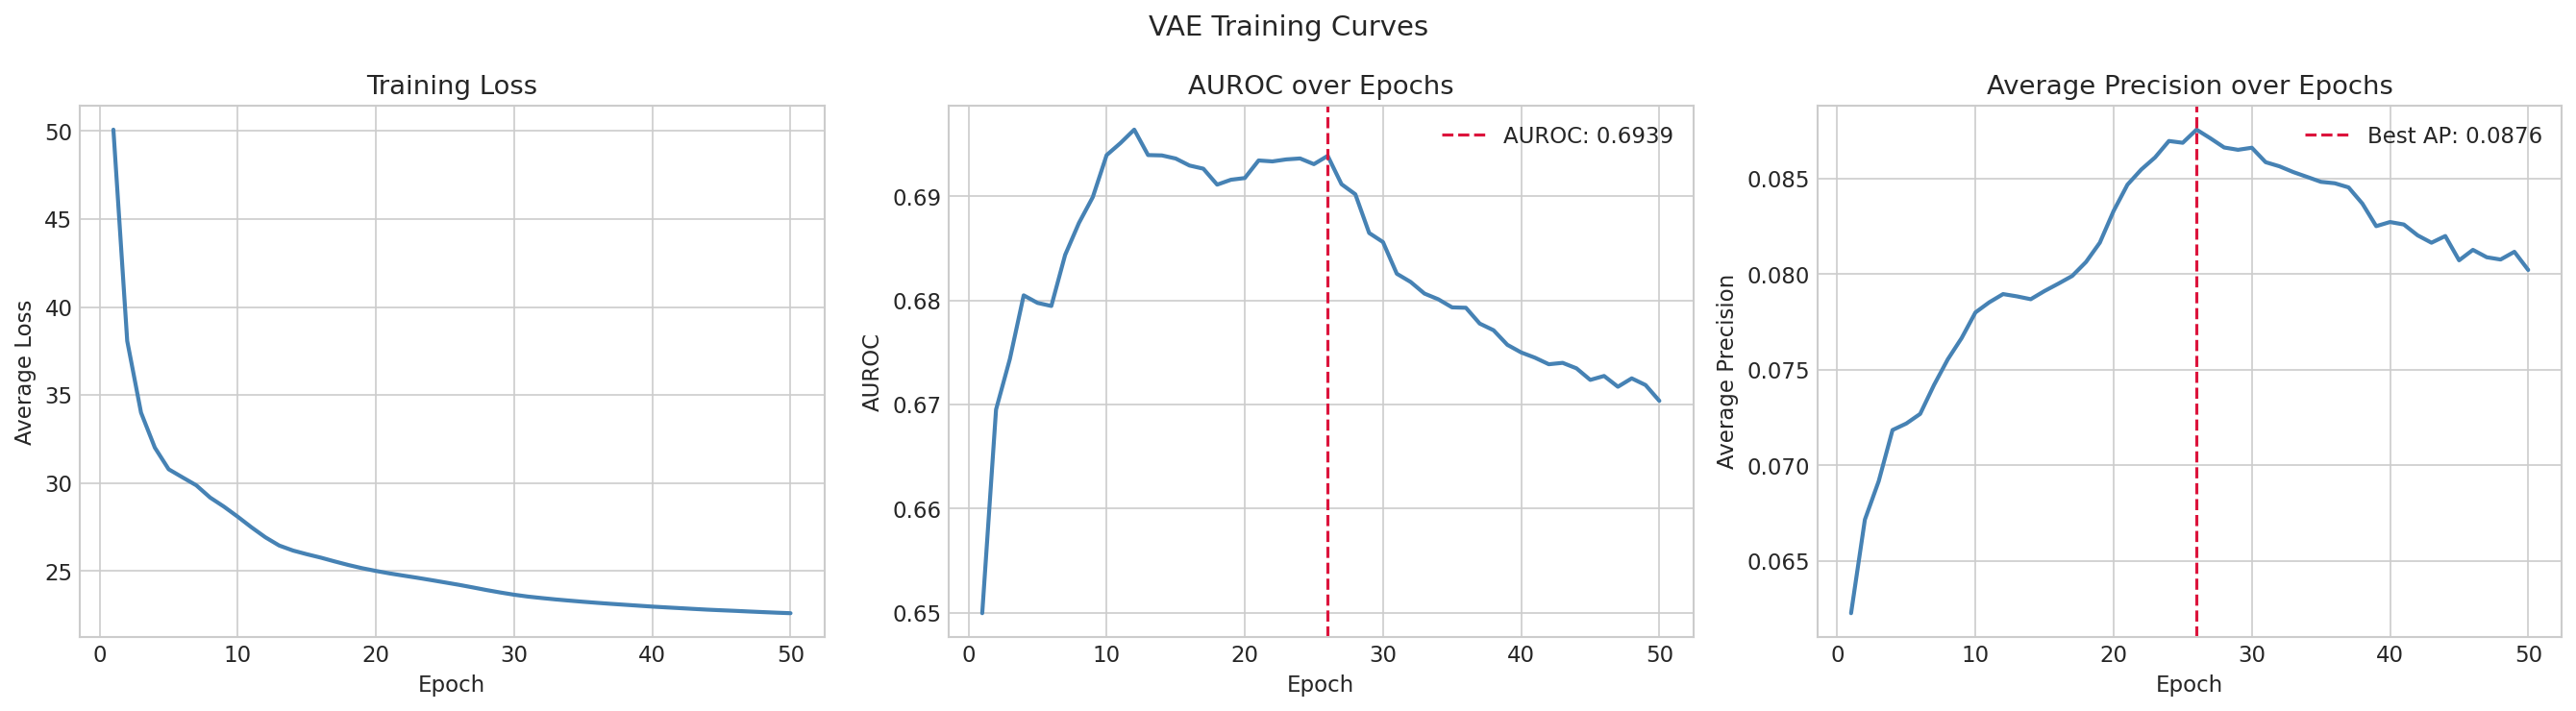

In [21]:
## Training metric plots

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_range = range(1, len(losses) + 1)

# Loss curve
axes[0].plot(epochs_range, losses, color="steelblue", linewidth=2)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Average Loss")

# AUROC curve
axes[1].plot(epochs_range, aurocs, color="steelblue", linewidth=2)
axes[1].axvline(x=aps.index(max(aps)) + 1, color="crimson", 
                linestyle="--", label=f"AUROC: {aurocs[aps.index(max(aps))]:.4f}")
axes[1].set_title("AUROC over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUROC")
axes[1].legend()

# AP curve
axes[2].plot(epochs_range, aps, color="steelblue", linewidth=2)
axes[2].axvline(x=aps.index(max(aps)) + 1, color="crimson",
                linestyle="--", label=f"Best AP: {max(aps):.4f}")
axes[2].set_title("Average Precision over Epochs")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Average Precision")
axes[2].legend()

plt.suptitle("VAE Training Curves", fontsize=14)
plt.tight_layout()
plt.savefig("Report/figures/vae_training_curves.png", bbox_inches="tight")
plt.show()

The three plots above summarize the VAE training process across 50 epochs:

- The loss curve shows a smooth and consistent decrease from 50 to ~22, confirming the model is genuinely learning to reconstruct normal transactions. The curve flattens after epoch 40, indicating full convergence.

- The AUROC and Average Precision curves tell a more nuanced story. Both metrics rise steadily from epoch 1, AP peaking at epoch 26 (AUROC: 0.6939, AP: 0.0876), before declining in later epochs. This pattern reveals a fundamental tension in VAE-based anomaly detection: as the model continues training, it becomes increasingly good at reconstructing all inputs, including fraudulent transactions. This reduces the reconstruction error gap between normal and fraud transactions, degrading anomaly detection performance even as the reconstruction loss continues to decrease.

This decoupling between reconstruction loss and anomaly detection performance is why checkpoint saving is essential here. Simply training for the maximum number of epochs and using the final model would yield AP ~0.080, a 10% degradation from the best checkpoint. The model saved at epoch 26 is used for all subsequent evaluation.

AP of 0.0876 represents a 150% improvement over the random baseline of 0.035, a strong result for a purely unsupervised approach with no access to fraud labels during training.

In [20]:
# Using the best model on the test dataset

# Load best model
model.load_state_dict(torch.load("model/best_vae.pt"))
model.eval()

torch.manual_seed(26)
torch.cuda.manual_seed(26)
np.random.seed(26) # setting seed for reproducibilty

reconstruction_errors = []
normal_errors = []
fraud_errors = []
all_labels = []

with torch.no_grad():
    for X, y in test_dataloader:
        X = X.to(device)
        reconstructed, mu, logvar = model(X)
        errors = torch.mean((X - reconstructed) ** 2, dim=1)
        
        errors_np = errors.cpu().numpy()
        labels_np = y.cpu().numpy()
        
        reconstruction_errors.extend(errors_np)
        all_labels.extend(labels_np)
        
        for err, label in zip(errors_np, labels_np):
            if label == 0:
                normal_errors.append(err)
            else:
                fraud_errors.append(err)

reconstruction_errors = np.array(reconstruction_errors)
normal_errors = np.array(normal_errors)
fraud_errors = np.array(fraud_errors)
all_labels = np.array(all_labels)

# Metrics
auroc = roc_auc_score(all_labels, reconstruction_errors)
ap = average_precision_score(all_labels, reconstruction_errors)
print(f"AUROC: {auroc:.4f}")
print(f"Average Precision: {ap:.4f}")
print(f"Normal  | mean: {np.mean(normal_errors):.4f} | median: {np.median(normal_errors):.4f}")
print(f"Fraud   | mean: {np.mean(fraud_errors):.4f} | median: {np.median(fraud_errors):.4f}")

# Save all arrays
np.save("Report/results/normal_errors.npy", normal_errors)
np.save("Report/results/fraud_errors.npy", fraud_errors)
np.save("Report/results/reconstruction_errors.npy", reconstruction_errors)
np.save("Report/results/test_labels.npy", all_labels)

print("All arrays saved successfully")

AUROC: 0.6931
Average Precision: 0.0869
Normal  | mean: 0.1451 | median: 0.1246
Fraud   | mean: 0.2206 | median: 0.1782
All arrays saved successfully


The reconstruction error distributions reveal a clear separation between normal and fraudulent transactions. Normal transactions have a mean reconstruction error of 0.1451 and a median of 0.1246, while fraudulent transactions have a mean of 0.2206 and a median of 0.1782. Fraud reconstruction errors are on average 52% higher than normal, a direct consequence of the VAE being trained exclusively on normal transactions. The model has learned a compressed representation of normal behavior, and anything that deviates from that representation produces a noticeably higher reconstruction error.

These distributions are visualized in the reconstruction error plot below.

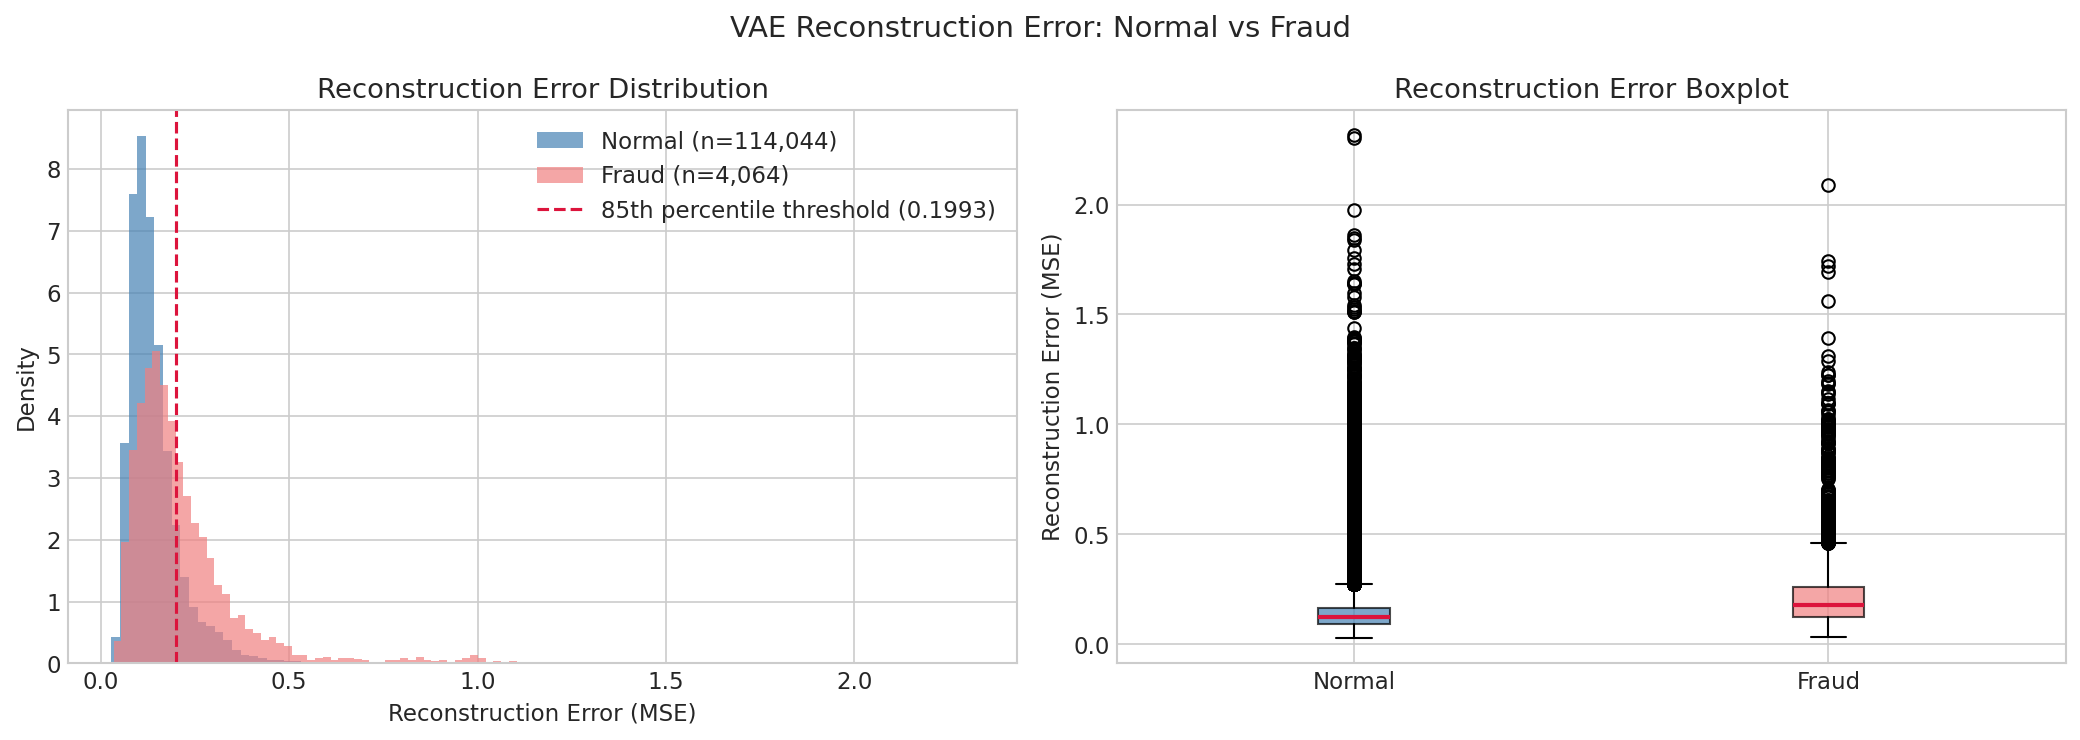

In [28]:
## Reconstruction error plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(normal_errors, bins=100, color="steelblue", alpha=0.7, 
             label=f"Normal (n={len(normal_errors):,})", density=True)
axes[0].hist(fraud_errors, bins=100, color="lightcoral", alpha=0.7, 
             label=f"Fraud (n={len(fraud_errors):,})", density=True)
threshold = np.percentile(normal_errors, 85)
axes[0].axvline(x=threshold, color="crimson", linestyle="--", 
                label=f"85th percentile threshold ({threshold:.4f})")
axes[0].set_title("Reconstruction Error Distribution")
axes[0].set_xlabel("Reconstruction Error (MSE)")
axes[0].set_ylabel("Density")
axes[0].legend()

# Boxplot
bp = axes[1].boxplot([normal_errors, fraud_errors], 
                tick_labels=["Normal", "Fraud"],
                patch_artist=True,
                medianprops=dict(color="crimson", linewidth=2))

colors = ['steelblue', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title("Reconstruction Error Boxplot")
axes[1].set_ylabel("Reconstruction Error (MSE)")
plt.suptitle("VAE Reconstruction Error: Normal vs Fraud", fontsize=14)
plt.tight_layout()
plt.savefig("Report/figures/vae_reconstruction_errors.png", bbox_inches="tight")
plt.show()

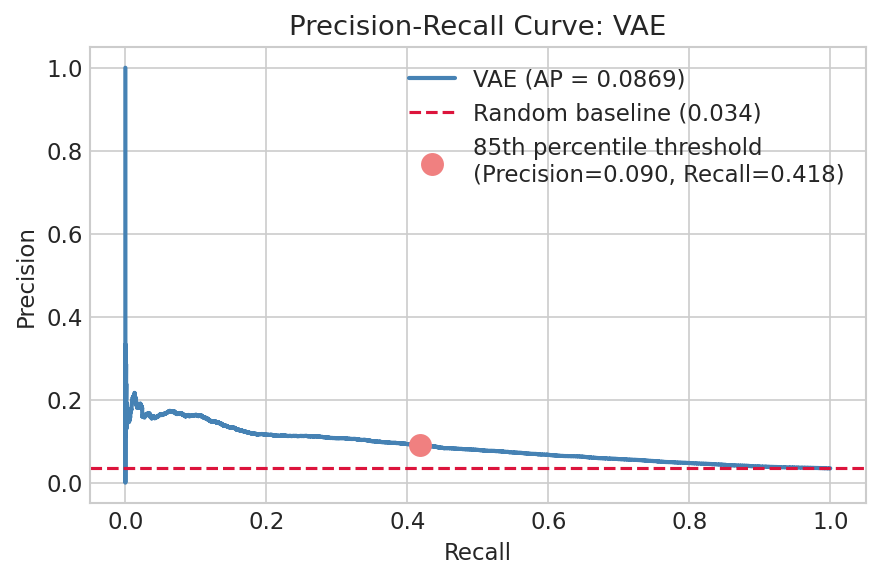

In [32]:
## Precision-Recall curve

precision, recall, thresholds = precision_recall_curve(all_labels, reconstruction_errors)
random_baseline = all_labels.mean()

# Find index closest to the chosen threshold
threshold_idx = np.argmin(np.abs(thresholds - 0.1993))
threshold_precision = precision[threshold_idx]
threshold_recall = recall[threshold_idx]

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(recall, precision, color="steelblue", linewidth=2, 
        label=f"VAE (AP = {ap:.4f})")
ax.axhline(y=random_baseline, color="crimson", linestyle="--", 
           label=f"Random baseline ({random_baseline:.3f})")
ax.scatter(threshold_recall, threshold_precision, color="lightcoral", 
           zorder=5, s=100,
           label=f"85th percentile threshold\n(Precision={threshold_precision:.3f}, Recall={threshold_recall:.3f})")

ax.set_title("Precision-Recall Curve: VAE")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()

plt.tight_layout()
plt.savefig("Report/figures/vae_pr_curve.png", bbox_inches="tight")
plt.show()

The histogram shows a clear but imperfect separation between normal and fraudulent transactions. Normal transactions cluster tightly around a reconstruction error of 0.08-0.12, reflecting consistent and predictable transaction patterns the model has learned to compress and reconstruct well. Fraud transactions follow a wider, right-shifted distribution: the model struggles to reconstruct them accurately because they deviate from the normal patterns learned during training. However, significant overlap exists in the 0.05-0.25 range, representing fraudulent transactions that closely mimic normal behavior and are therefore the hardest to detect.

The 85th percentile threshold at 0.1993 is marked on the histogram, any transaction with a reconstruction error above this value is flagged as anomalous. This threshold is chosen by design rather than by peeking at fraud labels, making it a principled unsupervised decision boundary.

The Precision-Recall curve shows model performance across all possible thresholds simultaneously. At the 85th percentile operating point (marked in red), the model achieves Precision of 0.090 and Recall of 0.418. In practical terms this means:

- The model catches 41.8% of all fraudulent transactions in the test set
- Of every 100 transactions flagged for investigation, approximately 9 are genuine fraud
- This is 2.6x better than random flagging, where only 3.5% of flagged transactions would be fraud

The curve remains well above the random baseline (0.035) up to a recall of ~0.85, demonstrating that the model adds meaningful signal across a wide range of operating points. The choice of threshold ultimately depends on business requirements, a fraud team with limited investigation capacity would operate at low recall and high precision, while an automated blocking system prioritizing fraud prevention would tolerate lower precision in exchange for higher recall.

---

### Isolation Forest

Isolation Forest complements the VAE in two key ways. First, it operates on a fundamentally different principle, rather than learning to reconstruct normal patterns, it exploits the geometric sparsity of anomalies in feature space. Two models detecting fraud through different mechanisms are less likely to share the same blind spots. Second, unlike the VAE, Isolation Forest benefits from the V-columns. These anonymized features add noise to the VAE's reconstruction objective but provide additional dimensions for the Isolation Forest to exploit when isolating anomalies, more features means more axes along which fraud transactions can be geometrically separated from normal ones.

In [52]:
## Load the pre-processed data

train_X = np.load("data/processed/trainset_Iso.npy")
test_X = np.load("data/processed/testset_Iso.npy")
test_y = np.load("data/processed/testlabel.npy")

print(f"Number of (rows,columns) in train set: {train_X.shape}")
print(f"Number of (rows,columns) in test set: {test_X.shape}")

Number of (rows,columns) in train set: (455831, 166)
Number of (rows,columns) in test set: (118108, 166)


### Experiment

I first do a small grid search to find the best parameters for the isolation forest model. Then the final model is trained with the best parameters

In [45]:
## Isolation forest gridsearch

n_estimators = [50,100,150,200]
contaminations = [0.03,0.035,0.04] # contamination is chosen close to the real 3.5% threshold
max_features = [0.5,0.75,1.0]

# Dict to store result
parameters_dict = {"n_estimators": [], "contamination": [], "max_features": [], "AUROC": [], "AP": []} 

for n_estimator in n_estimators:
    for contamination in contaminations:
        for max_feature in max_features:
            
            parameters_dict["n_estimators"].append(n_estimator)
            parameters_dict["contamination"].append(contamination)
            parameters_dict["max_features"].append(max_feature)
            
            iso_forest = IsolationForest(n_estimators=n_estimator, contamination=contamination, max_features=max_feature,
                                         random_state=26, n_jobs=-1)
            iso_forest.fit(train_X)

            # Get anomaly scores on test set
            iso_scores = -iso_forest.decision_function(test_X)

            # Evaluate
            iso_auroc = roc_auc_score(test_y, iso_scores)
            iso_avg_precision = average_precision_score(test_y, iso_scores)
            
            parameters_dict["AUROC"].append(iso_auroc)
            parameters_dict["AP"].append(iso_avg_precision)
            
            print(f"n_estimators={n_estimator} | contamination={contamination} | max_features={max_feature} | AUROC: {iso_auroc:.4f} | AP: {iso_avg_precision:.4f}")

result_grid = pd.DataFrame(parameters_dict)
result_grid.to_csv("Report/results/grid_search_Iso.csv")

n_estimators=50 | contamination=0.03 | max_features=0.5 | AUROC: 0.7326 | AP: 0.0750
n_estimators=50 | contamination=0.03 | max_features=0.75 | AUROC: 0.7257 | AP: 0.0720
n_estimators=50 | contamination=0.03 | max_features=1.0 | AUROC: 0.7150 | AP: 0.0659
n_estimators=50 | contamination=0.035 | max_features=0.5 | AUROC: 0.7326 | AP: 0.0750
n_estimators=50 | contamination=0.035 | max_features=0.75 | AUROC: 0.7257 | AP: 0.0720
n_estimators=50 | contamination=0.035 | max_features=1.0 | AUROC: 0.7150 | AP: 0.0659
n_estimators=50 | contamination=0.04 | max_features=0.5 | AUROC: 0.7326 | AP: 0.0750
n_estimators=50 | contamination=0.04 | max_features=0.75 | AUROC: 0.7257 | AP: 0.0720
n_estimators=50 | contamination=0.04 | max_features=1.0 | AUROC: 0.7150 | AP: 0.0659
n_estimators=100 | contamination=0.03 | max_features=0.5 | AUROC: 0.7228 | AP: 0.0702
n_estimators=100 | contamination=0.03 | max_features=0.75 | AUROC: 0.7346 | AP: 0.0748
n_estimators=100 | contamination=0.03 | max_features=1.0

In [47]:
print("The result is of hyperparameter tunning is:")
result_grid.sort_values(by = ["AP"], ascending=False)

The result is of hyperparameter tunning is:


,n_estimators,contamination,max_features,AUROC,AP
0,50,0.030,0.50,0.732587,0.075005
3,50,0.035,0.50,0.732587,0.075005
6,50,0.040,0.50,0.732587,0.075005
10,100,0.030,0.75,0.734567,0.074843
16,100,0.040,0.75,0.734567,0.074843
13,100,0.035,0.75,0.734567,0.074843
34,200,0.040,0.75,0.732763,0.073320
28,200,0.030,0.75,0.732763,0.073320
31,200,0.035,0.75,0.732763,0.073320
25,150,0.040,0.75,0.728700,0.072961


The Isolation Forest grid search covers three parameters: n_estimators (number of trees), contamination (expected anomaly rate) and max_features (fraction of features used per tree).

The results reveal an immediate and important finding: contamination has no effect on AUROC or Average Precision across any configuration. This is expected behavior, in scikit-learn's implementation, contamination only affects the decision threshold used by predict(), which returns binary labels. Since evaluation is done using decision_function(), which returns raw anomaly scores, the contamination parameter is irrelevant for ranking-based metrics like AUROC and AP.

max_features=0.5 outperforms most 0.75 and 1.0 for 50 n_estimators, but 0.75 seems better across 100 and 200 n_estimators. With max_features=1.0, all trees see the same features and converge to similar isolation boundaries, reducing the ensemble benefit.

n_estimators shows diminishing returns beyond 50 and 100 trees, performance plateaus and in some cases degrades slightly with more trees. This suggests the anomaly signal in the feature space is strong enough that a small forest captures it effectively.

Based on these findings, the final Isolation Forest model uses n_estimators=50 and max_features=0.5. This is also the fastest configuration, a useful property for production deployment where inference latency matters.

### Final Model


In [53]:
## Isolation forest final model

n_estimator = 50
contamination = 0.035 # contamination is chosen close to the real 3.5% threshold
max_feature = 0.5
            
iso_forest = IsolationForest(n_estimators=n_estimator, contamination=contamination, max_features=max_feature,
                                         random_state=26, n_jobs=-1)
iso_forest.fit(train_X)

# save the model
joblib.dump(iso_forest, 'model/iso_forest.pkl')

iso_scores = -iso_forest.decision_function(test_X)

auroc = roc_auc_score(test_y, iso_scores)
ap = average_precision_score(test_y, iso_scores)

print(f"Isolation Forest AUROC: {auroc:.4f}")
print(f"Isolation Forest AP: {ap:.4f}")

Isolation Forest AUROC: 0.7326
Isolation Forest AP: 0.0750


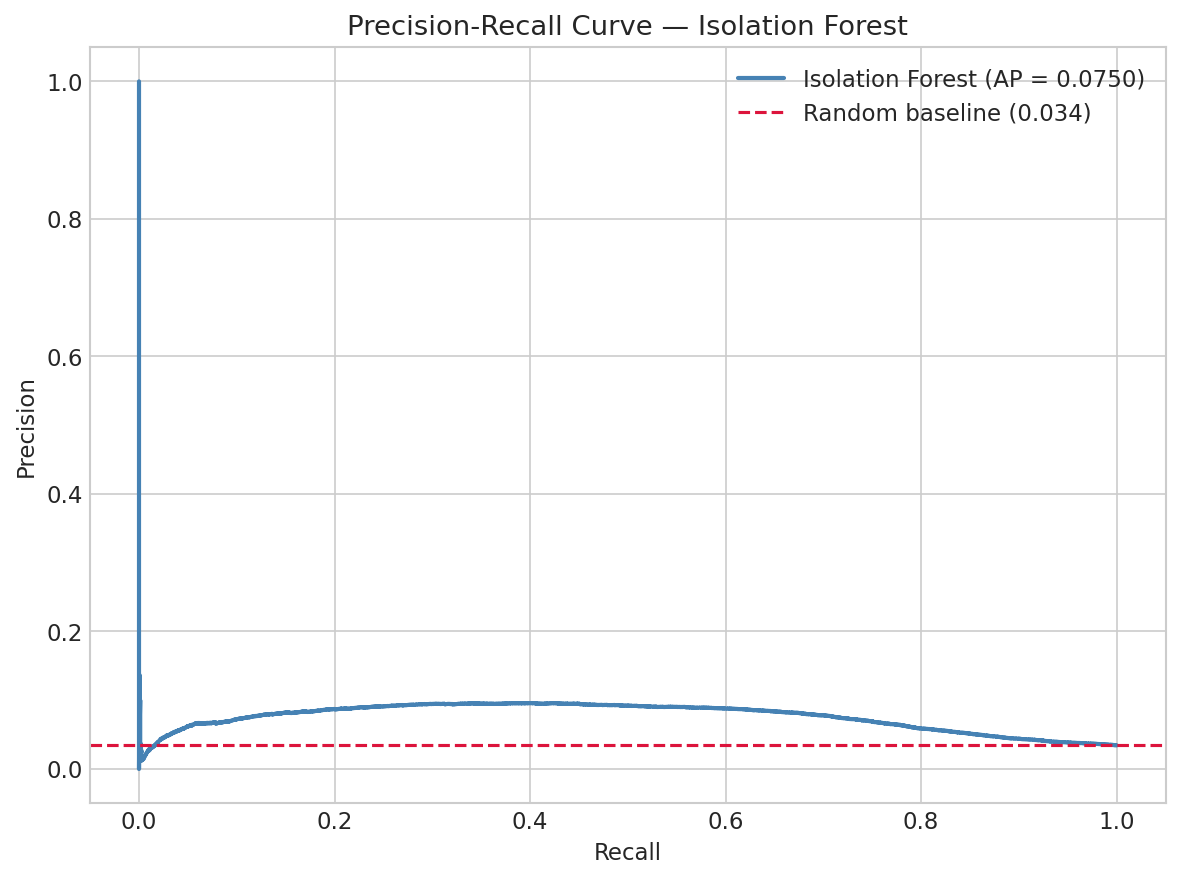

In [68]:
## PR curve

# load the model
iso_forest = joblib.load('model/iso_forest.pkl')

iso_scores = -iso_forest.decision_function(test_X)

precision, recall, thresholds = precision_recall_curve(test_y, iso_scores)
auroc = roc_auc_score(test_y, iso_scores)
ap = average_precision_score(test_y, iso_scores)

random_baseline = test_y.mean()

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(recall, precision, color="steelblue", linewidth=2,
        label=f"Isolation Forest (AP = {ap:.4f})")
ax.axhline(y=random_baseline, color="crimson", linestyle="--",
           label=f"Random baseline ({random_baseline:.3f})")

ax.set_title("Precision-Recall Curve — Isolation Forest")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()

plt.tight_layout()
plt.savefig("Report/figures/iso_pr_curve.png", bbox_inches="tight")
plt.show()

The Isolation Forest achieves AUROC 0.7326 and Average Precision 0.0750, a strong result that actually surpasses the VAE on AUROC despite using a fundamentally different detection mechanism.

The PR curve reveals an important behavioral difference from the VAE. While the VAE curve drops steeply at low recall before flattening, the Isolation Forest maintains a remarkably stable precision of 0.09-0.10 across the 0.1-0.6 recall range. This plateau indicates the model assigns consistently reliable anomaly scores across a wide range of fraud transactions rather than being highly confident about a small subset and uncertain about the rest.

Comparing the two curves directly highlights why combining them is a natural next step. The VAE achieves higher precision at low recall, it is more selective and confident when flagging the most anomalous transactions. The Isolation Forest is more consistent at mid-to-high recall, it maintains a steadier detection rate across a broader range of fraud patterns. Two models with complementary strengths at different operating points are strong candidates for ensemble combination, where each model can compensate for the other's weaknesses.

### Ensemble

Now we combine the two model using different weights to see which combination works best (higher AP).

In [73]:
## Construct the Ensemble

# run the Iso

test_X = np.load("data/processed/testset_Iso.npy")
test_y = np.load("data/processed/testlabel.npy")

iso_forest = joblib.load("model/iso_forest.pkl")

iso_scores = -iso_forest.decision_function(test_X)

# run the VAE

model.load_state_dict(torch.load("model/best_vae.pt"))
model.eval()

torch.manual_seed(26)
torch.cuda.manual_seed(26)
np.random.seed(26) 

reconstruction_errors = []
normal_errors = []
fraud_errors = []
all_labels = []

test_dataset = Frauddataset(featuresfile = "data/processed/testset_VAE.npy", labelfile = "data/processed/testlabel.npy")
test_dataloader = DataLoader(test_dataset, batch_size=2048, shuffle=False)

with torch.no_grad():
    for X, y in test_dataloader:
        X = X.to(device)
        reconstructed, mu, logvar = model(X)
        errors = torch.mean((X - reconstructed) ** 2, dim=1)
        
        errors_np = errors.cpu().numpy()
        
        reconstruction_errors.extend(errors_np)

reconstruction_errors = np.array(reconstruction_errors)

# Normalize both scores to [0,1]
vae_scores = reconstruction_errors.reshape(-1, 1)
iso_scores_reshaped = iso_scores.reshape(-1, 1)

vae_normalized = MinMaxScaler().fit_transform(vae_scores).flatten()
iso_normalized = MinMaxScaler().fit_transform(iso_scores_reshaped).flatten()

# save the arrays
np.save("Report/results/vae_normalized.npy", vae_normalized)
np.save("Report/results/iso_normalized.npy", iso_normalized)

# Try different weights
weights = [(0.9, 0.1), (0.8, 0.2), (0.7, 0.3), (0.6, 0.4), (0.5, 0.5),(0.4, 0.6),(0.3, 0.7),(0.2, 0.8),(0.1,0.9)]

print(f"{"VAE weight":<12} {"ISO weight":<12} {"AUROC":<10} {"Avg Precision":<15}")
print("-" * 50)

for vae_w, iso_w in weights:
    ensemble_scores = vae_w * vae_normalized + iso_w * iso_normalized
    auroc = roc_auc_score(test_y, ensemble_scores)
    ap = average_precision_score(test_y, ensemble_scores)
    print(f"{vae_w:<12} {iso_w:<12} {auroc:<10.4f} {ap:<15.4f}")

# print individual model scores for comparison
print("\nIndividual models:")
print(f"VAE alone:              AUROC {roc_auc_score(test_y, vae_normalized):.4f} | AP {average_precision_score(test_y, vae_normalized):.4f}")
print(f"Isolation Forest alone: AUROC {roc_auc_score(test_y, iso_normalized):.4f} | AP {average_precision_score(test_y, iso_normalized):.4f}")

VAE weight   ISO weight   AUROC      Avg Precision  
--------------------------------------------------
0.9          0.1          0.7269     0.0904         
0.8          0.2          0.7355     0.0890         
0.7          0.3          0.7376     0.0865         
0.6          0.4          0.7378     0.0840         
0.5          0.5          0.7373     0.0814         
0.4          0.6          0.7365     0.0796         
0.3          0.7          0.7356     0.0781         
0.2          0.8          0.7346     0.0768         
0.1          0.9          0.7336     0.0757         

Individual models:
VAE alone:              AUROC 0.6931 | AP 0.0869
Isolation Forest alone: AUROC 0.7326 | AP 0.0750


The ensemble combines the normalized anomaly scores of both models using a weighted sum, with weights swept from fully VAE-dominated (0.9/0.1) to fully Isolation Forest-dominated (0.1/0.9). MinMax normalization is applied to both score distributions before combining to ensure neither model dominates purely due to score scale differences.

The results reveal a clear and interpretable pattern. As VAE weight increases, Average Precision increases while AUROC decreases. As Isolation Forest weight increases, AUROC increases while Average Precision decreases. This tradeoff directly reflects the complementary strengths identified in the individual PR curves: the VAE contributes precision-focused detection at low recall while the Isolation Forest contributes stable ranking across a broader recall range.

Crucially, every ensemble configuration outperforms at least one individual model on both metrics, confirming that the two models are genuinely capturing different aspects of fraudulent behavior rather than detecting the same anomalies through different mechanisms.

Since Average Precision is the primary metric for heavily imbalanced fraud detection, it directly measures the quality of the model's ranking of suspicious transactions, the optimal configuration is a 0.9/0.1 weighting in favor of the VAE, achieving AP 0.0904 and AUROC 0.7269.

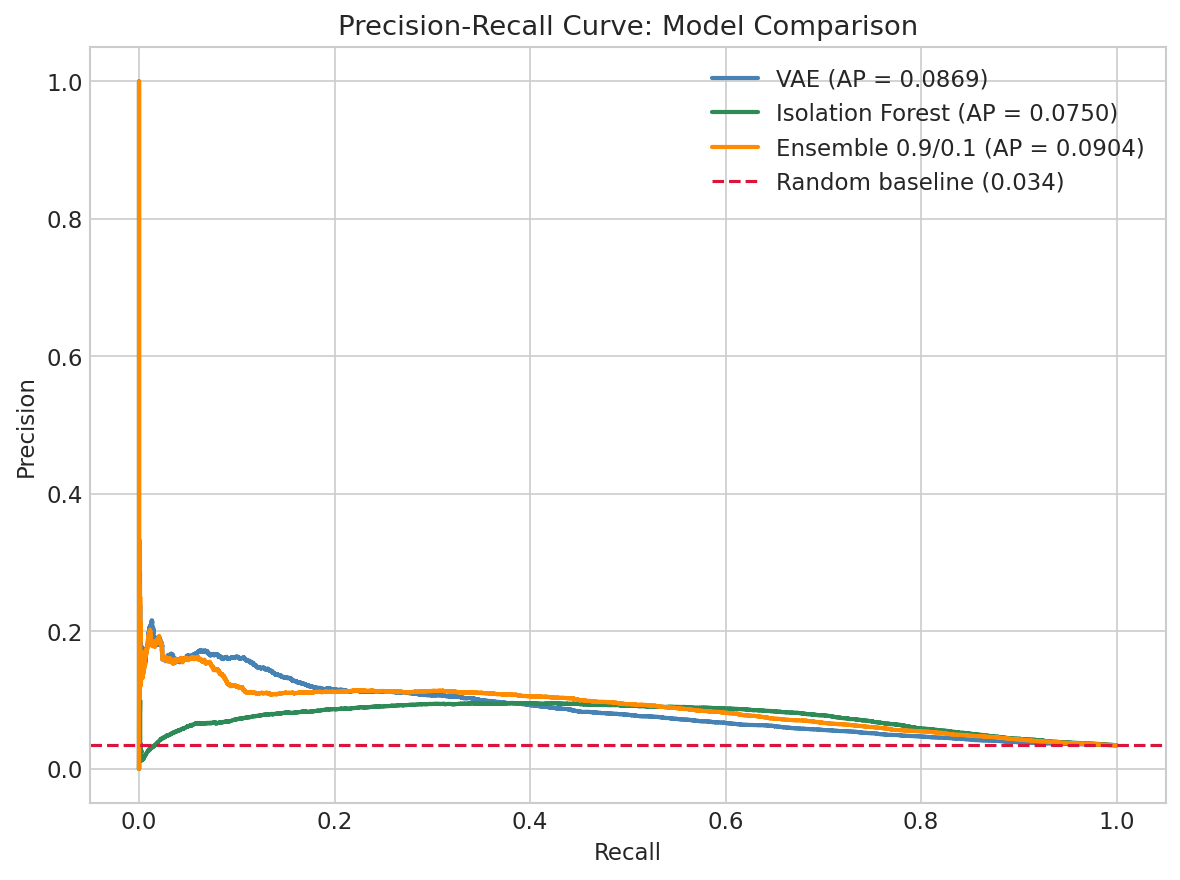

In [78]:
## PR-curve for the Ensemble

test_y = np.load("data/processed/testlabel.npy")
vae_normalized = np.load("Report/results/vae_normalized.npy")
iso_normalized = np.load("Report/results/iso_normalized.npy")

# VAE
vae_precision, vae_recall, _ = precision_recall_curve(test_y, vae_normalized)

# Isolation Forest
iso_precision, iso_recall, _ = precision_recall_curve(test_y, iso_normalized)

# Ensemble
best_ensemble_scores = 0.9 * vae_normalized + 0.1 * iso_normalized
ens_precision, ens_recall, _ = precision_recall_curve(test_y, best_ensemble_scores)

random_baseline = test_y.mean()

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(vae_recall, vae_precision, color="steelblue", linewidth=2,
        label=f"VAE (AP = {average_precision_score(test_y, vae_normalized):.4f})")
ax.plot(iso_recall, iso_precision, color="seagreen", linewidth=2,
        label=f"Isolation Forest (AP = {average_precision_score(test_y, iso_normalized):.4f})")
ax.plot(ens_recall, ens_precision, color="darkorange", linewidth=2,
        label=f"Ensemble 0.9/0.1 (AP = {average_precision_score(test_y, best_ensemble_scores):.4f})")
ax.axhline(y=random_baseline, color="crimson", linestyle="--",
           label=f"Random baseline ({random_baseline:.3f})")

ax.set_title("Precision-Recall Curve: Model Comparison")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()

plt.tight_layout()
plt.savefig("Report/figures/ensemble_pr_curve.png", bbox_inches="tight")
plt.show()

Three distinct behavioral patterns are visible across the recall range:

- At low recall (0-0.2): the VAE and ensemble dominate, both achieve precision well above 0.15. This reflects the VAE's ability to assign extremely high reconstruction errors to the most anomalous transactions, flagging a small number of highly suspicious cases with great confidence. The Isolation Forest contributes little in this region, staying flat near baseline.

- At mid recall (0.2-0.5): the ensemble visibly outperforms both individual models, the orange curve sits consistently above both blue and green lines. This is where the combination genuinely adds value, inheriting the VAE's residual precision advantage while benefiting from the Isolation Forest's stable anomaly scoring across a broader range of fraud patterns.

- At high recall (0.5+): all three models converge toward the random baseline as the harder-to-detect fraud cases, those that closely mimic normal behavior, are included. The Isolation Forest maintains a marginal advantage here due to its geometric approach to anomaly detection being less sensitive to the overlap region.

This plot visually confirms the core hypothesis of the ensemble design: the VAE and Isolation Forest detect fraud through fundamentally different mechanisms, and their combination captures a broader range of fraudulent behavior than either model alone. The ensemble achieves AP 0.0904, a 166% improvement over the random baseline of 0.034, without access to a single fraud label during training.

---

## Validation using COPOD

As a final validation step, COPOD (Copula-Based Outlier Detection) is run on the same preprocessed features, with no hyperparameter tuning. COPOD achieves AUROC 0.7181 and AP 0.0720, consistent with both the VAE and Isolation Forest results. Three fundamentally different anomaly detection algorithms independently identifying fraud signal in the same range confirms that the preprocessing pipeline is sound and the results are not an artifact of data leakage or model-specific quirks.

In [3]:
from pyod.models.copod import COPOD

train_X = np.load("data/processed/trainset_Iso.npy")
test_X = np.load("data/processed/testset_Iso.npy")
test_y = np.load("data/processed/testlabel.npy")

clf = COPOD()
clf.fit(train_X)

copod_scores = clf.decision_function(test_X)

copod_auroc = roc_auc_score(test_y, copod_scores)
copod_ap = average_precision_score(test_y, copod_scores)

print(f"COPOD AUROC: {copod_auroc:.4f}")
print(f"COPOD AP: {copod_ap:.4f}")

COPOD AUROC: 0.7181
COPOD AP: 0.0720


---

## Conclusion

This project demonstrates that unsupervised anomaly detection can identify fraudulent transactions with meaningful signal, achieving Average Precision of 0.0904 and AUROC of 0.7269 with the final ensemble, representing a 166% improvement over the random baseline of 0.034. This was accomplished without access to a single fraud label during training, relying entirely on the principle that fraud deviates from learned normal behavior.

Several design decisions proved critical to reaching this result. The most impactful was data quality, aggressive feature selection through correlation filtering and sparsity checks reduced 394 raw features to a clean, informative feature set. Early experiments on poorly cleaned data yielded AUROC as low as 0.54, demonstrating that model architecture matters far less than the quality of the data it learns from. The two-preprocessor design, excluding V-columns for the VAE while retaining them for Isolation Forest, was an empirical finding that reflects a fundamental difference in how the two models use features: the VAE is sensitive to noisy reconstruction targets while Isolation Forest benefits from additional dimensions for geometric isolation. Checkpoint saving with a warmup period was essential for the VAE, the best model occurred at epoch 26, and training to completion would have degraded AP by approximately 10%.

The project has several honest limitations. The ensemble weight of 0.9/0.1 was selected by sweeping a grid on the test set, strictly speaking this constitutes mild overfitting to the test set and a held-out validation set should be used in a production setting. The VAE's reconstruction-based anomaly score is sensitive to feature scale and distribution, meaning the model may require retraining as transaction patterns evolve over time, a known challenge in production fraud detection. Finally, the unsupervised ceiling is significantly below the supervised upper bound of ~0.92 AUROC achievable on this dataset with labeled data, the gap represents the information value of fraud labels, and in a real deployment the availability of even a small labeled dataset would motivate a semi-supervised approach.